# Leverage Analysis: Carry + Puts Across All FX Pairs

How does leverage interact with tail hedging? This notebook runs the Spitznagel carry+puts strategy
at multiple leverage levels (1x through 10x) for all FX carry pairs vs JPY and analyzes:

- **Kelly-optimal leverage**: the leverage maximizing geometric growth rate (CAGR)
- **Sharpe vs leverage**: hedging should make Sharpe *increase* with leverage (convex put payoffs)
- **Max drawdown scaling**: unhedged is roughly linear, hedged should be sub-linear
- **Blow-up frontier**: at what leverage does each pair go to zero?
- **Portfolio effects**: diversification + hedging together on optimal leverage
- **Put budget sensitivity**: optimal hedge ratio at given leverage

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '../data/databento'
MONTH_CODES = {'F':1,'G':2,'H':3,'J':4,'K':5,'M':6,
               'N':7,'Q':8,'U':9,'V':10,'X':11,'Z':12}

# Color scheme for pairs
COLORS = {'AUD': '#1f77b4', 'GBP': '#d62728', 'CAD': '#2ca02c',
          'EUR': '#9467bd', 'MXN': '#ff7f0e'}

LEVERAGE_LEVELS = [1, 2, 3, 5, 7, 10]
ANALYSIS_PAIRS = ['AUD', 'GBP', 'CAD', 'EUR', 'MXN']  # skip CHF (neg carry), NZD (thin opts)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

## 1. Data Loading

Reuse `load_front_month()` from multi_asset_carry.ipynb. Load all FX futures and build cross rates vs JPY.

In [2]:
def load_front_month(filename):
    """Load futures data and build roll-adjusted front-month series."""
    fut = pd.read_parquet(f'{DATA_DIR}/{filename}')
    outrights = fut[~fut['symbol'].str.contains('-', na=False)].copy()
    outrights = outrights.sort_index()

    # Per-contract price history for roll adjustment
    contract_prices = {}
    for _, row in outrights.iterrows():
        sym = row['symbol']
        date = row.name.normalize().tz_localize(None)
        if sym not in contract_prices:
            contract_prices[sym] = {}
        contract_prices[sym][date] = row['close']

    # Identify front-month (highest volume) per day
    daily_front = {}
    for date, group in outrights.groupby(outrights.index.date):
        best = group.sort_values('volume', ascending=False).iloc[0]
        daily_front[pd.Timestamp(date)] = {
            'symbol': best['symbol'],
            'close': best['close'],
            'volume': best['volume'],
        }

    # Build roll-adjusted return series
    dates = sorted(daily_front.keys())
    records = []
    prev_date = None
    prev_symbol = None

    for date in dates:
        info = daily_front[date]
        cur_symbol = info['symbol']

        if prev_date is None:
            records.append({'date': date, 'close': info['close'], 'return': 0.0})
            prev_date = date
            prev_symbol = cur_symbol
            continue

        if cur_symbol == prev_symbol:
            prev_price = contract_prices.get(prev_symbol, {}).get(prev_date, 0)
            cur_price = contract_prices.get(cur_symbol, {}).get(date, 0)
            ret = cur_price / prev_price - 1 if prev_price > 0 else 0.0
        else:
            old_prev = contract_prices.get(prev_symbol, {}).get(prev_date, 0)
            old_cur = contract_prices.get(prev_symbol, {}).get(date, 0)
            ret = old_cur / old_prev - 1 if old_prev > 0 and old_cur > 0 else 0.0

        records.append({'date': date, 'close': info['close'], 'return': ret})
        prev_date = date
        prev_symbol = cur_symbol

    return pd.DataFrame(records).set_index('date')


# Load all FX futures
fx_futures = {}
pairs = {
    'AUD': '6A_FUT_ohlcv1d.parquet',
    'GBP': '6B_FUT_ohlcv1d.parquet',
    'CAD': '6C_FUT_ohlcv1d.parquet',
    'EUR': '6E_FUT_ohlcv1d.parquet',
    'CHF': '6S_FUT_ohlcv1d.parquet',
    'MXN': '6M_FUT_ohlcv1d.parquet',
    'NZD': '6N_FUT_ohlcv1d.parquet',
    'JPY': '6J_FUT_ohlcv1d.parquet',
}

for ccy, filename in pairs.items():
    print(f'Loading {ccy} futures...')
    fx_futures[ccy] = load_front_month(filename)
    f = fx_futures[ccy]
    print(f'  {len(f)} days, {f.index.min().date()} to {f.index.max().date()}, '
          f'close: {f["close"].iloc[-1]:.6f}')

# Build cross rates vs JPY
jpy = fx_futures['JPY']

cross_rates = {}
for ccy in ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN', 'NZD']:
    f = fx_futures[ccy]
    common = f.index.intersection(jpy.index)
    cross = pd.DataFrame({
        f'{ccy.lower()}_jpy': f.loc[common, 'close'] / jpy.loc[common, 'close'],
        'ccy_ret': f.loc[common, 'return'],
        'jpy_ret': jpy.loc[common, 'return'],
        'cross_ret': f.loc[common, 'return'] - jpy.loc[common, 'return'],
    }, index=common)
    cross_rates[ccy] = cross

    spot_col = f'{ccy.lower()}_jpy'
    years = (cross.index[-1] - cross.index[0]).days / 365.25
    total = cross[spot_col].iloc[-1] / cross[spot_col].iloc[0]
    cagr = total**(1/years) - 1
    print(f'{ccy}/JPY: {len(cross)} days, spot CAGR {cagr*100:.2f}%')

Loading AUD futures...


  4880 days, 2010-06-06 to 2026-02-27, close: 0.711500
Loading GBP futures...


  4880 days, 2010-06-06 to 2026-02-27, close: 1.348300
Loading CAD futures...


  4880 days, 2010-06-06 to 2026-02-27, close: 0.733500
Loading EUR futures...


  4880 days, 2010-06-06 to 2026-02-27, close: 1.182350
Loading CHF futures...


  4880 days, 2010-06-06 to 2026-02-27, close: 1.301650
Loading MXN futures...


  4877 days, 2010-06-06 to 2026-02-27, close: 0.057990
Loading NZD futures...


  4879 days, 2010-06-06 to 2026-02-27, close: 0.600050
Loading JPY futures...


  4880 days, 2010-06-06 to 2026-02-27, close: 0.006417
AUD/JPY: 4880 days, spot CAGR 2.53%
GBP/JPY: 4880 days, spot CAGR 2.99%
CAD/JPY: 4880 days, spot CAGR 1.82%
EUR/JPY: 4880 days, spot CAGR 3.38%
CHF/JPY: 4880 days, spot CAGR 6.20%
MXN/JPY: 4877 days, spot CAGR 1.65%
NZD/JPY: 4879 days, spot CAGR 2.73%


## 2. Carry Rates

Same policy rate series as multi_asset_carry.ipynb for all central banks.

In [3]:
# Historical policy rates (annual averages, %)
boj_rates = {y: 0.0 for y in range(2010, 2027)}
boj_rates[2024] = 0.25
boj_rates[2025] = 0.50
boj_rates[2026] = 0.50

policy_rates = {
    'AUD': {
        2010: 4.25, 2011: 4.50, 2012: 3.50, 2013: 2.75, 2014: 2.50,
        2015: 2.00, 2016: 1.75, 2017: 1.50, 2018: 1.50, 2019: 1.00,
        2020: 0.25, 2021: 0.10, 2022: 1.85, 2023: 4.10, 2024: 4.35,
        2025: 4.35, 2026: 4.10,
    },
    'GBP': {
        2010: 0.50, 2011: 0.50, 2012: 0.50, 2013: 0.50, 2014: 0.50,
        2015: 0.50, 2016: 0.25, 2017: 0.35, 2018: 0.65, 2019: 0.75,
        2020: 0.25, 2021: 0.15, 2022: 2.00, 2023: 4.75, 2024: 5.00,
        2025: 4.50, 2026: 4.25,
    },
    'CAD': {
        2010: 0.50, 2011: 1.00, 2012: 1.00, 2013: 1.00, 2014: 1.00,
        2015: 0.75, 2016: 0.50, 2017: 0.75, 2018: 1.50, 2019: 1.75,
        2020: 0.50, 2021: 0.25, 2022: 2.50, 2023: 4.75, 2024: 4.50,
        2025: 3.25, 2026: 3.00,
    },
    'EUR': {
        2010: 1.00, 2011: 1.25, 2012: 0.75, 2013: 0.50, 2014: 0.15,
        2015: 0.05, 2016: 0.00, 2017: 0.00, 2018: 0.00, 2019: 0.00,
        2020: 0.00, 2021: 0.00, 2022: 1.25, 2023: 4.00, 2024: 4.25,
        2025: 3.15, 2026: 2.65,
    },
    'CHF': {
        2010: 0.25, 2011: 0.00, 2012: 0.00, 2013: 0.00, 2014: 0.00,
        2015: -0.75, 2016: -0.75, 2017: -0.75, 2018: -0.75, 2019: -0.75,
        2020: -0.75, 2021: -0.75, 2022: 0.25, 2023: 1.50, 2024: 1.50,
        2025: 0.50, 2026: 0.25,
    },
    'MXN': {
        2010: 4.50, 2011: 4.50, 2012: 4.50, 2013: 4.00, 2014: 3.50,
        2015: 3.25, 2016: 5.00, 2017: 7.00, 2018: 8.00, 2019: 8.00,
        2020: 5.00, 2021: 4.50, 2022: 8.50, 2023: 11.25, 2024: 10.75,
        2025: 9.50, 2026: 8.50,
    },
    'NZD': {
        2010: 3.00, 2011: 2.50, 2012: 2.50, 2013: 2.50, 2014: 3.25,
        2015: 2.75, 2016: 2.00, 2017: 1.75, 2018: 1.75, 2019: 1.25,
        2020: 0.50, 2021: 0.50, 2022: 2.75, 2023: 5.50, 2024: 5.50,
        2025: 4.25, 2026: 3.50,
    },
}

# Attach daily carry to each cross rate DataFrame
for ccy in cross_rates:
    cr = cross_rates[ccy]
    cr['ccy_rate'] = cr.index.year.map(lambda y: policy_rates[ccy].get(y, 0)) / 100
    cr['jpn_rate'] = cr.index.year.map(lambda y: boj_rates.get(y, 0)) / 100
    cr['daily_carry'] = (cr['ccy_rate'] - cr['jpn_rate']) / 365

# Summary
print(f'{"Pair":>10} {"Avg carry":>10} {"2010":>7} {"2015":>7} {"2020":>7} {"2023":>7} {"2025":>7}')
print('-' * 60)
for ccy in ANALYSIS_PAIRS:
    cr = cross_rates[ccy]
    avg = cr['daily_carry'].mean() * 365 * 100
    row = f'{ccy}/JPY:  {avg:>8.2f}%'
    for yr in [2010, 2015, 2020, 2023, 2025]:
        diff = policy_rates[ccy].get(yr, 0) - boj_rates.get(yr, 0)
        row += f' {diff:>6.2f}%'
    print(row)

      Pair  Avg carry    2010    2015    2020    2023    2025
------------------------------------------------------------
AUD/JPY:      2.43%   4.25%   2.00%   0.25%   4.10%   3.85%
GBP/JPY:      1.36%   0.50%   0.50%   0.25%   4.75%   4.00%
CAD/JPY:      1.59%   0.50%   0.75%   0.50%   4.75%   2.75%
EUR/JPY:      0.99%   1.00%   0.05%   0.00%   4.00%   2.65%
MXN/JPY:      6.39%   4.50%   3.25%   5.00%  11.25%   9.00%


## 3. Option Loading and Selection

Load FX options for all pairs, parse them, and select monthly 8% OTM puts.

In [4]:
STRIKE_DIVISORS = {
    'AUD': 1000, 'GBP': 1000, 'CAD': 1000, 'EUR': 1000,
    'CHF': 1000, 'NZD': 1000, 'MXN': 10000, 'JPY': 100000,
}

OPT_CONFIGS = {
    'AUD': ('6A_OPT_ohlcv1d.parquet', 'ADU_OPT_ohlcv1d.parquet',
            ['6A'], ['ADU'], '2016-08-23'),
    'GBP': ('6B_OPT_ohlcv1d.parquet', 'GBU_OPT_ohlcv1d.parquet',
            ['6B'], ['GBU'], '2016-08-23'),
    'CAD': ('6C_OPT_ohlcv1d.parquet', 'CAU_OPT_ohlcv1d.parquet',
            ['6C'], ['CAU'], '2016-08-22'),
    'EUR': ('6E_OPT_ohlcv1d.parquet', 'EUU_OPT_ohlcv1d.parquet',
            ['6E'], ['EUU'], '2016-08-09'),
    'CHF': ('6S_OPT_ohlcv1d.parquet', None,
            ['6S'], None, None),
    'MXN': ('6M_OPT_ohlcv1d.parquet', None,
            ['6M'], None, None),
    'NZD': ('6N_OPT_ohlcv1d.parquet', None,
            ['6N'], None, None),
}


def parse_option_generic(sym, date_year, prefixes, strike_div):
    """Parse CME FX option symbol -> (month, year, opt_type, strike)."""
    parts = sym.split()
    if len(parts) != 2:
        return None
    contract, opt = parts
    opt_type = opt[0]
    if opt_type not in ('C', 'P'):
        return None
    try:
        strike_raw = int(opt[1:])
    except ValueError:
        return None

    strike = strike_raw / strike_div

    month_code = None
    year_digit = None
    for pfx in prefixes:
        if contract.startswith(pfx):
            rest = contract[len(pfx):]
            if len(rest) >= 2:
                month_code = rest[0]
                try:
                    year_digit = int(rest[1])
                except ValueError:
                    continue
                break

    if month_code is None or year_digit is None:
        return None

    month = MONTH_CODES.get(month_code, 0)
    if month == 0:
        return None

    decade_base = (date_year // 10) * 10
    year = decade_base + year_digit
    if year < date_year - 2:
        year += 10

    return month, year, opt_type, strike


def load_fx_options_generic(ccy):
    """Load FX options for a given currency, merging old + new format files."""
    config = OPT_CONFIGS[ccy]
    old_file, new_file, old_prefixes, new_prefixes, cutoff = config
    strike_div = STRIKE_DIVISORS[ccy]

    old = pd.read_parquet(f'{DATA_DIR}/{old_file}')
    old = old[~old['symbol'].str.contains('UD:', na=False)].copy()

    if new_file is not None:
        new = pd.read_parquet(f'{DATA_DIR}/{new_file}')
        new = new[~new['symbol'].str.contains('UD:', na=False)].copy()
        cutoff_ts = pd.Timestamp(cutoff, tz='UTC')
        old = old[old.index < cutoff_ts]
        combined = pd.concat([old, new]).sort_index()
        all_prefixes = old_prefixes + new_prefixes
    else:
        combined = old.sort_index()
        all_prefixes = old_prefixes

    records = []
    for idx, row in combined.iterrows():
        parsed = parse_option_generic(row['symbol'], idx.year, all_prefixes, strike_div)
        if parsed is None:
            continue
        month, year, opt_type, strike = parsed
        try:
            first_of_month = pd.Timestamp(year=year, month=month, day=1)
        except ValueError:
            continue
        third_wed = first_of_month + pd.offsets.WeekOfMonth(week=2, weekday=2)
        expiry = (third_wed - pd.offsets.BDay(2)).tz_localize('UTC')
        records.append({
            'date': idx, 'symbol': row['symbol'], 'opt_type': opt_type,
            'strike': strike, 'expiry': expiry,
            'close': row['close'], 'volume': row['volume'],
        })

    return pd.DataFrame(records)


def select_monthly_options(opts, front_prices, opt_type='P', otm_target=0.92):
    """Select one OTM option per month."""
    filtered = opts[opts['opt_type'] == opt_type].copy()
    if len(filtered) == 0:
        return pd.DataFrame()

    prices = front_prices[['close']].rename(columns={'close': 'fut_close'})
    prices.index = prices.index.tz_localize('UTC')
    filtered['date_norm'] = filtered['date'].dt.normalize()
    filtered = filtered.merge(prices, left_on='date_norm', right_index=True, how='left')
    filtered = filtered.dropna(subset=['fut_close'])
    filtered['moneyness'] = filtered['strike'] / filtered['fut_close']
    filtered['year_month'] = filtered['date'].dt.to_period('M')

    selections = []
    for ym, group in filtered.groupby('year_month'):
        first_day = group['date'].min()
        day_opts = group[group['date'] == first_day]
        if len(day_opts) == 0:
            continue

        day_opts = day_opts[day_opts['expiry'] > first_day + pd.Timedelta(days=14)]
        if len(day_opts) == 0:
            continue
        nearest_exp = day_opts['expiry'].min()
        day_opts = day_opts[day_opts['expiry'] == nearest_exp]

        if opt_type == 'P':
            day_opts = day_opts[day_opts['moneyness'] < 1.0]
        else:
            day_opts = day_opts[day_opts['moneyness'] > 1.0]

        if len(day_opts) == 0:
            continue

        day_opts = day_opts.copy()
        day_opts['dist'] = (day_opts['moneyness'] - otm_target).abs()
        candidates = day_opts.nsmallest(5, 'dist')
        best = candidates.sort_values('volume', ascending=False).iloc[0]

        if best['close'] <= 0:
            continue

        selections.append({
            'entry_date': first_day,
            'symbol': best['symbol'],
            'strike': best['strike'],
            'entry_price': best['close'],
            'expiry': best['expiry'],
            'underlying': best['fut_close'],
            'moneyness': best['moneyness'],
            'volume': best['volume'],
        })

    return pd.DataFrame(selections)


# Load options for all analysis pairs
fx_options = {}
for ccy in ANALYSIS_PAIRS:
    print(f'Loading {ccy} options...')
    opts = load_fx_options_generic(ccy)
    fx_options[ccy] = opts
    puts = (opts['opt_type'] == 'P').sum()
    calls = (opts['opt_type'] == 'C').sum()
    print(f'  {len(opts):,} total (puts: {puts:,}, calls: {calls:,}), '
          f'{opts["date"].min().date()} to {opts["date"].max().date()}')

# Select 8% OTM puts for each pair
put_selections = {}
empty_sels = pd.DataFrame(columns=['entry_date', 'symbol', 'strike', 'entry_price',
                                    'expiry', 'underlying', 'moneyness', 'volume'])

for ccy in ANALYSIS_PAIRS:
    front = pd.DataFrame({'close': fx_futures[ccy]['close']})
    sels = select_monthly_options(fx_options[ccy], front, opt_type='P', otm_target=0.92)
    put_selections[ccy] = sels
    if len(sels) > 0:
        print(f'{ccy} puts: {len(sels)} months, '
              f'{sels["entry_date"].min().date()} to {sels["entry_date"].max().date()}, '
              f'avg moneyness {sels["moneyness"].mean():.3f}')
    else:
        print(f'{ccy} puts: no selections')

Loading AUD options...


  281,447 total (puts: 150,657, calls: 130,790), 2010-06-06 to 2026-02-27
Loading GBP options...


  291,950 total (puts: 151,965, calls: 139,985), 2010-06-06 to 2026-02-27
Loading CAD options...


  209,251 total (puts: 110,536, calls: 98,715), 2010-06-06 to 2026-02-27
Loading EUR options...


  612,216 total (puts: 317,901, calls: 294,315), 2010-06-06 to 2026-02-27
Loading MXN options...
  7,576 total (puts: 3,955, calls: 3,621), 2013-01-22 to 2026-02-27


AUD puts: 182 months, 2010-06-07 to 2026-02-01, avg moneyness 0.955
GBP puts: 124 months, 2010-06-07 to 2021-02-01, avg moneyness 0.962


CAD puts: 180 months, 2010-06-06 to 2025-12-01, avg moneyness 0.974
EUR puts: 185 months, 2010-06-06 to 2026-02-01, avg moneyness 0.959


MXN puts: 121 months, 2013-02-05 to 2026-02-02, avg moneyness 0.968


## 3. Backtest Engine

Same engine as multi_asset_carry.ipynb with settlement pre-computation.

In [5]:
def build_settlement_lookup(opts):
    """Pre-build symbol -> [(date, price)] for fast settlement."""
    lookup = {}
    for _, row in opts.iterrows():
        sym = row['symbol']
        if sym not in lookup:
            lookup[sym] = []
        lookup[sym].append((row['date'], row['close']))
    for sym in lookup:
        lookup[sym].sort(key=lambda x: x[0])
    return lookup


def get_settlement(symbol, strike, expiry, opt_type, lookup, front_prices):
    """Get option settlement price."""
    window_start = expiry - pd.Timedelta(days=5)
    window_end = expiry + pd.Timedelta(days=2)
    if symbol in lookup:
        near = [(d, p) for d, p in lookup[symbol] if window_start <= d <= window_end]
        if near:
            return near[-1][1]
    # Fallback: intrinsic value
    near_dates = front_prices[
        (front_prices.index >= (expiry - pd.Timedelta(days=3)).tz_localize(None)) &
        (front_prices.index <= (expiry + pd.Timedelta(days=3)).tz_localize(None))
    ]
    if len(near_dates) > 0:
        underlying = near_dates.iloc[-1]['close']
        if opt_type == 'P':
            return max(0, strike - underlying)
        else:
            return max(0, underlying - strike)
    return 0.0


def precompute_settlements(selections, opt_type, lookup, front_prices):
    """Pre-compute settlement for all selected options."""
    put_map = {}
    for _, row in selections.iterrows():
        settle = get_settlement(row['symbol'], row['strike'], row['expiry'],
                                opt_type, lookup, front_prices)
        entry_price = row['entry_price']
        pnl_ratio = (settle - entry_price) / entry_price if entry_price > 0 else 0
        put_map[row['entry_date']] = {
            'symbol': row['symbol'],
            'strike': row['strike'],
            'entry_price': entry_price,
            'settlement': settle,
            'pnl_ratio': pnl_ratio,
            'moneyness': row['moneyness'],
        }
    return put_map


def run_carry_backtest(cross_df, front_prices, put_sels, all_opts,
                       leverage=1, put_budget=0.005):
    """Run leveraged carry + puts backtest for a single pair.

    Args:
        cross_df: DataFrame with daily_carry, cross_ret columns
        front_prices: DataFrame with close column (for settlement fallback)
        put_sels: DataFrame of selected put options
        all_opts: DataFrame of all options (for settlement lookup)
        leverage: leverage multiplier
        put_budget: fraction of notional for puts per month (0 = unhedged)
    """
    if put_budget > 0 and len(put_sels) > 0:
        lookup = build_settlement_lookup(all_opts)
        put_map = precompute_settlements(put_sels, 'P', lookup, front_prices)
    else:
        put_map = {}

    capital = 100.0
    records = []
    current_month = None

    for date in cross_df.index:
        if capital <= 0:
            records.append({'date': date, 'capital': 0, 'daily_carry': 0,
                            'daily_spot': 0, 'put_pnl': 0})
            continue

        notional = capital * leverage
        carry_income = notional * cross_df.loc[date, 'daily_carry']
        spot_pnl = notional * cross_df.loc[date, 'cross_ret']

        put_pnl = 0
        ym = pd.Timestamp(date).to_period('M')
        if ym != current_month:
            current_month = ym
            date_tz = pd.Timestamp(date, tz='UTC')
            if put_budget > 0 and date_tz in put_map:
                cost = put_budget * notional
                put_pnl = cost * put_map[date_tz]['pnl_ratio']

        capital += carry_income + spot_pnl + put_pnl
        records.append({
            'date': date, 'capital': capital, 'daily_carry': carry_income,
            'daily_spot': spot_pnl, 'put_pnl': put_pnl,
        })

    return pd.DataFrame(records).set_index('date')


def compute_stats(capital_series):
    """Compute comprehensive strategy stats from capital series."""
    cap = capital_series[capital_series > 0]
    if len(cap) < 252:
        return None
    daily_ret = cap.pct_change().dropna()
    years = (cap.index[-1] - cap.index[0]).days / 365.25
    total_ret = cap.iloc[-1] / cap.iloc[0]
    ann_ret = total_ret ** (1/years) - 1
    ann_vol = daily_ret.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    max_dd = (cap / cap.cummax() - 1).min()

    downside = daily_ret[daily_ret < 0]
    downside_std = downside.std() * np.sqrt(252) if len(downside) > 1 else ann_vol
    sortino = ann_ret / downside_std if downside_std > 0 else 0

    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0

    skew = daily_ret.skew()
    kurt = daily_ret.kurtosis()

    # Max drawdown duration
    drawdown = cap / cap.cummax() - 1
    in_dd = drawdown < 0
    dd_groups = (~in_dd).cumsum()
    if in_dd.any():
        dd_durations = in_dd.groupby(dd_groups).sum()
        max_dd_days = int(dd_durations.max())
    else:
        max_dd_days = 0

    # Geometric growth rate (log)
    log_growth = np.log(total_ret) / years if total_ret > 0 else -np.inf

    # Yearly returns for win rate
    yearly_ret = cap.resample('YE').last().pct_change().dropna()
    pct_positive_years = (yearly_ret > 0).mean() * 100

    return {
        'ann_ret': ann_ret, 'ann_vol': ann_vol, 'sharpe': sharpe,
        'sortino': sortino, 'calmar': calmar,
        'max_dd': max_dd, 'max_dd_days': max_dd_days,
        'skew': skew, 'kurt': kurt,
        'pct_pos_years': pct_positive_years,
        'total': total_ret, 'log_growth': log_growth,
    }


def build_equal_weight_portfolio(results_dict, pairs, leverage, hedged):
    """Build equal-weight portfolio from multiple carry pair backtests."""
    daily_rets = {}
    for ccy in pairs:
        key = (ccy, leverage, hedged)
        if key not in results_dict:
            key = (ccy, leverage, False)
        if key not in results_dict:
            continue
        cap = results_dict[key]['capital']
        cap = cap[cap > 0]
        daily_rets[ccy] = cap.pct_change().fillna(0)

    if not daily_rets:
        return None

    ret_df = pd.DataFrame(daily_rets)
    ret_df = ret_df.dropna()
    port_ret = ret_df.mean(axis=1)
    capital = (1 + port_ret).cumprod() * 100
    return capital


print('Engine ready.')

Engine ready.


## 4. Leverage Sweep

Run the backtest at leverage levels [1, 2, 3, 5, 7, 10] for each pair, both hedged and unhedged.
This produces 5 pairs x 6 leverage levels x 2 = 60 backtests.

In [6]:
# Pre-build settlement lookups once per pair (expensive step)
settlement_lookups = {}
precomputed_puts = {}
for ccy in ANALYSIS_PAIRS:
    sels = put_selections.get(ccy, empty_sels)
    opts = fx_options.get(ccy, pd.DataFrame())
    front = pd.DataFrame({'close': fx_futures[ccy]['close']})
    if len(sels) >= 12 and len(opts) > 0:
        lookup = build_settlement_lookup(opts)
        settlement_lookups[ccy] = lookup
        precomputed_puts[ccy] = precompute_settlements(sels, 'P', lookup, front)
        print(f'{ccy}: pre-computed {len(precomputed_puts[ccy])} put settlements')
    else:
        print(f'{ccy}: insufficient option data for hedging')

AUD: pre-computed 182 put settlements


GBP: pre-computed 124 put settlements


CAD: pre-computed 180 put settlements


EUR: pre-computed 185 put settlements
MXN: pre-computed 121 put settlements


In [7]:
def run_carry_backtest_fast(cross_df, put_map, leverage=1, put_budget=0.005):
    """Faster backtest using pre-computed put settlements.

    Args:
        cross_df: DataFrame with daily_carry, cross_ret columns
        put_map: pre-computed settlement map (from precompute_settlements), or {} for unhedged
        leverage: leverage multiplier
        put_budget: fraction of notional for puts per month (0 = unhedged)
    """
    capital = 100.0
    records = []
    current_month = None
    daily_carry_col = cross_df['daily_carry'].values
    cross_ret_col = cross_df['cross_ret'].values
    dates = cross_df.index

    for i in range(len(dates)):
        date = dates[i]
        if capital <= 0:
            records.append({'date': date, 'capital': 0.0})
            continue

        notional = capital * leverage
        carry_income = notional * daily_carry_col[i]
        spot_pnl = notional * cross_ret_col[i]

        put_pnl = 0.0
        ym = pd.Timestamp(date).to_period('M')
        if ym != current_month:
            current_month = ym
            if put_budget > 0 and put_map:
                date_tz = pd.Timestamp(date, tz='UTC')
                if date_tz in put_map:
                    cost = put_budget * notional
                    put_pnl = cost * put_map[date_tz]['pnl_ratio']

        capital += carry_income + spot_pnl + put_pnl
        records.append({'date': date, 'capital': capital})

    return pd.DataFrame(records).set_index('date')


# Run all backtests
all_results = {}  # {(ccy, leverage, hedged): backtest_df}

total = len(ANALYSIS_PAIRS) * len(LEVERAGE_LEVELS) * 2
count = 0

for ccy in ANALYSIS_PAIRS:
    cr = cross_rates[ccy]
    put_map = precomputed_puts.get(ccy, {})
    has_hedge = ccy in precomputed_puts

    for lev in LEVERAGE_LEVELS:
        # Unhedged
        count += 1
        print(f'[{count}/{total}] {ccy}/JPY {lev}x unhedged...')
        all_results[(ccy, lev, False)] = run_carry_backtest_fast(
            cr, {}, leverage=lev, put_budget=0
        )

        # Hedged
        count += 1
        if has_hedge:
            print(f'[{count}/{total}] {ccy}/JPY {lev}x hedged...')
            all_results[(ccy, lev, True)] = run_carry_backtest_fast(
                cr, put_map, leverage=lev, put_budget=0.005
            )
        else:
            print(f'[{count}/{total}] {ccy}/JPY {lev}x hedged (skipped, no options)')

print(f'\nDone! {len(all_results)} backtests completed.')

[1/60] AUD/JPY 1x unhedged...
[2/60] AUD/JPY 1x hedged...
[3/60] AUD/JPY 2x unhedged...
[4/60] AUD/JPY 2x hedged...
[5/60] AUD/JPY 3x unhedged...
[6/60] AUD/JPY 3x hedged...


[7/60] AUD/JPY 5x unhedged...
[8/60] AUD/JPY 5x hedged...
[9/60] AUD/JPY 7x unhedged...
[10/60] AUD/JPY 7x hedged...
[11/60] AUD/JPY 10x unhedged...
[12/60] AUD/JPY 10x hedged...
[13/60] GBP/JPY 1x unhedged...


[14/60] GBP/JPY 1x hedged...
[15/60] GBP/JPY 2x unhedged...
[16/60] GBP/JPY 2x hedged...
[17/60] GBP/JPY 3x unhedged...


[18/60] GBP/JPY 3x hedged...
[19/60] GBP/JPY 5x unhedged...
[20/60] GBP/JPY 5x hedged...
[21/60] GBP/JPY 7x unhedged...
[22/60] GBP/JPY 7x hedged...
[23/60] GBP/JPY 10x unhedged...
[24/60] GBP/JPY 10x hedged...


[25/60] CAD/JPY 1x unhedged...
[26/60] CAD/JPY 1x hedged...
[27/60] CAD/JPY 2x unhedged...


...

[35/60] CAD/JPY 10x unhedged...
[36/60] CAD/JPY 10x hedged...
[37/60] EUR/JPY 1x unhedged...
[38/60] EUR/JPY 1x hedged...
[39/60] EUR/JPY 2x unhedged...


[40/60] EUR/JPY 2x hedged...
[41/60] EUR/JPY 3x unhedged...
[42/60] EUR/JPY 3x hedged...
[43/60] EUR/JPY 5x unhedged...
[44/60] EUR/JPY 5x hedged...
[45/60] EUR/JPY 7x unhedged...
[46/60] EUR/JPY 7x hedged...


[47/60] EUR/JPY 10x unhedged...
[48/60] EUR/JPY 10x hedged...
[49/60] MXN/JPY 1x unhedged...
[50/60] MXN/JPY 1x hedged...
[51/60] MXN/JPY 2x unhedged...


[52/60] MXN/JPY 2x hedged...
[53/60] MXN/JPY 3x unhedged...
[54/60] MXN/JPY 3x hedged...
[55/60] MXN/JPY 5x unhedged...
[56/60] MXN/JPY 5x hedged...
[57/60] MXN/JPY 7x unhedged...
[58/60] MXN/JPY 7x hedged...


[59/60] MXN/JPY 10x unhedged...
[60/60] MXN/JPY 10x hedged...

Done! 60 backtests completed.


## 5. Results Overview

Full stats table for all backtests.

In [8]:
# Collect stats into a DataFrame for analysis
stats_rows = []
for (ccy, lev, hedged), df in all_results.items():
    cap = df['capital']
    s = compute_stats(cap)
    if s is None:
        # Strategy blew up or too short
        s = {'ann_ret': np.nan, 'ann_vol': np.nan, 'sharpe': np.nan,
             'sortino': np.nan, 'calmar': np.nan, 'max_dd': np.nan,
             'max_dd_days': np.nan, 'skew': np.nan, 'kurt': np.nan,
             'pct_pos_years': np.nan, 'total': np.nan, 'log_growth': -np.inf}
    # Check for blow-up (capital hit zero)
    blew_up = (cap <= 0).any()
    final_cap = cap.iloc[-1]
    stats_rows.append({
        'pair': f'{ccy}/JPY', 'ccy': ccy, 'leverage': lev,
        'hedged': hedged, 'blew_up': blew_up,
        'final_capital': final_cap, **s
    })

stats_df = pd.DataFrame(stats_rows)

# Print summary table
for ccy in ANALYSIS_PAIRS:
    print('=' * 130)
    print(f'{ccy}/JPY LEVERAGE SWEEP')
    print('=' * 130)
    print(f'{"Lev":>4} {"Type":>10} {"CAGR":>8} {"Vol":>7} {"Sharpe":>7} {"Sortino":>8} '
          f'{"Calmar":>7} {"MaxDD":>7} {"Skew":>6} {"Kurt":>6} {"Total":>8} {"Blowup":>7}')
    print('-' * 130)
    sub = stats_df[stats_df['ccy'] == ccy].sort_values(['leverage', 'hedged'])
    for _, row in sub.iterrows():
        htype = 'hedged' if row['hedged'] else 'unhedged'
        blowup = 'YES' if row['blew_up'] else 'no'
        if pd.isna(row['ann_ret']):
            print(f'{row["leverage"]:>4}x {htype:>10} {"BLEW UP":>8}')
        else:
            print(f'{row["leverage"]:>4}x {htype:>10} {row["ann_ret"]*100:>7.2f}% '
                  f'{row["ann_vol"]*100:>6.1f}% {row["sharpe"]:>7.3f} '
                  f'{row["sortino"]:>8.3f} {row["calmar"]:>7.3f} '
                  f'{row["max_dd"]*100:>6.1f}% {row["skew"]:>6.2f} '
                  f'{row["kurt"]:>6.1f} {row["total"]:>7.1f}x {blowup:>7}')
    print()

AUD/JPY LEVERAGE SWEEP
 Lev       Type     CAGR     Vol  Sharpe  Sortino  Calmar   MaxDD   Skew   Kurt    Total  Blowup
----------------------------------------------------------------------------------------------------------------------------------
   1x   unhedged    6.85%   11.1%   0.619    0.844   0.244  -28.1%  -0.25    3.2     2.8x      no
   1x     hedged   14.08%   19.0%   0.743    1.715   0.621  -22.7%  21.21  786.2     7.9x      no
   2x   unhedged   12.45%   22.1%   0.563    0.767   0.239  -52.1%  -0.25    3.2     6.3x      no
   2x     hedged   26.10%   37.9%   0.688    1.589   0.614  -42.5%  21.21  786.2    38.4x      no
   3x   unhedged   16.56%   33.2%   0.499    0.680   0.235  -70.5%  -0.25    3.2    11.1x      no
   3x     hedged   35.82%   56.9%   0.629    1.454   0.608  -58.9%  21.21  786.2   123.4x      no
   5x   unhedged   19.60%   55.3%   0.354    0.483   0.214  -91.4%  -0.25    3.2    16.7x      no
   5x     hedged   47.21%   94.8%   0.498    1.150   0.578  -81

## 6. Optimal Leverage (Kelly Criterion)

For each pair, find the leverage that maximizes geometric growth rate (CAGR). The Kelly criterion
says optimal leverage = mean_excess_return / variance. With tail hedging, the variance is truncated,
so optimal leverage should shift higher.

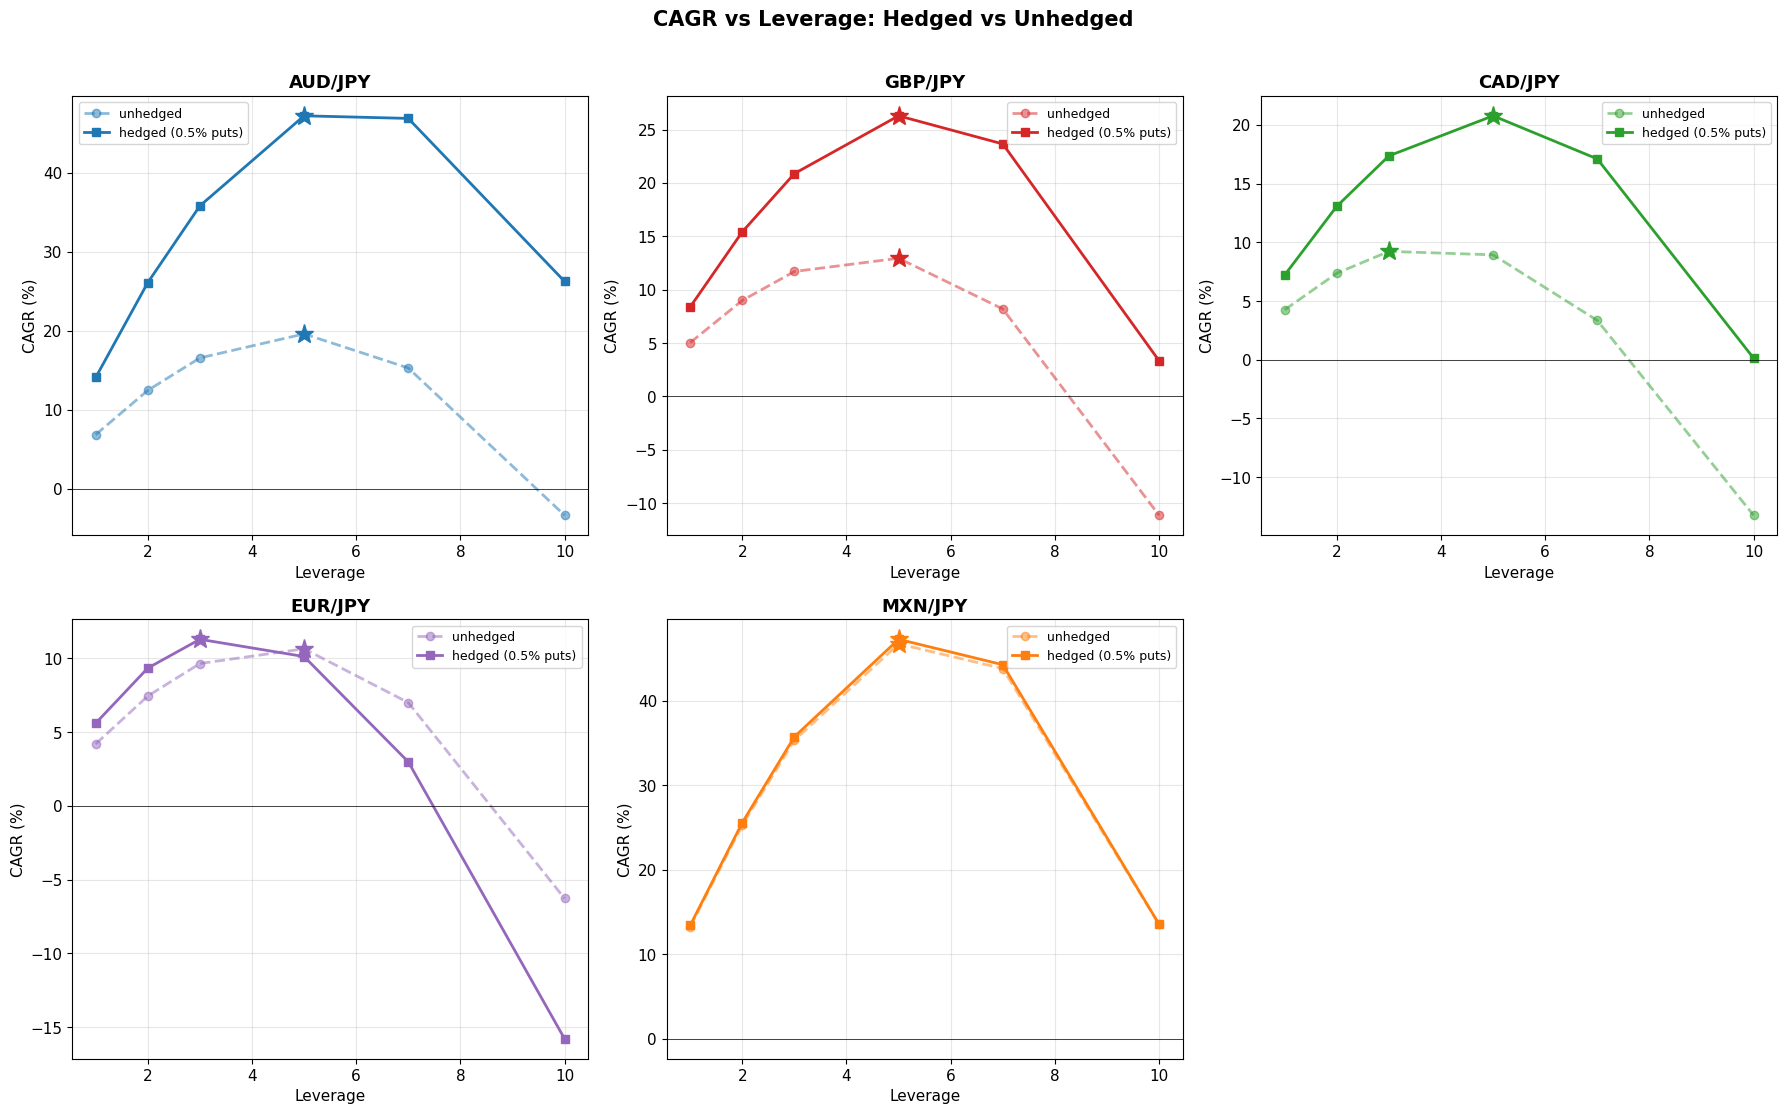


KELLY-OPTIMAL LEVERAGE
      Pair       Type  Opt Lev   Max CAGR
------------------------------------------------------------
   AUD/JPY   unhedged       5x     19.60%
   AUD/JPY     hedged       5x     47.21%
   CAD/JPY   unhedged       3x      9.23%
   CAD/JPY     hedged       5x     20.77%
   EUR/JPY   unhedged       5x     10.65%
   EUR/JPY     hedged       3x     11.29%
   GBP/JPY   unhedged       5x     12.94%
   GBP/JPY     hedged       5x     26.28%
   MXN/JPY   unhedged       5x     46.70%
   MXN/JPY     hedged       5x     47.24%


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flatten()

kelly_results = []

for idx, ccy in enumerate(ANALYSIS_PAIRS):
    ax = axes_flat[idx]

    for hedged, ls, marker in [(False, '--', 'o'), (True, '-', 's')]:
        levs = []
        cagrs = []
        for lev in LEVERAGE_LEVELS:
            key = (ccy, lev, hedged)
            if key not in all_results:
                continue
            sub = stats_df[(stats_df['ccy'] == ccy) &
                           (stats_df['leverage'] == lev) &
                           (stats_df['hedged'] == hedged)]
            if len(sub) == 0 or pd.isna(sub.iloc[0]['ann_ret']):
                continue
            levs.append(lev)
            cagrs.append(sub.iloc[0]['ann_ret'] * 100)

        if levs:
            label = 'hedged (0.5% puts)' if hedged else 'unhedged'
            color = COLORS[ccy]
            alpha = 1.0 if hedged else 0.5
            ax.plot(levs, cagrs, ls=ls, marker=marker, color=color,
                    alpha=alpha, label=label, linewidth=2, markersize=6)

            # Mark optimal
            best_idx = np.argmax(cagrs)
            ax.plot(levs[best_idx], cagrs[best_idx], '*', color=color,
                    markersize=14, zorder=5)
            kelly_results.append({
                'ccy': ccy, 'hedged': hedged,
                'kelly_lev': levs[best_idx], 'max_cagr': cagrs[best_idx],
            })

    ax.set_title(f'{ccy}/JPY', fontsize=13, fontweight='bold')
    ax.set_xlabel('Leverage')
    ax.set_ylabel('CAGR (%)')
    ax.legend(fontsize=9)
    ax.axhline(0, color='black', linewidth=0.5)

# Hide unused subplot
axes_flat[-1].set_visible(False)

fig.suptitle('CAGR vs Leverage: Hedged vs Unhedged', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print Kelly optimal summary
kelly_df = pd.DataFrame(kelly_results)
print('\nKELLY-OPTIMAL LEVERAGE')
print('=' * 60)
print(f'{"Pair":>10} {"Type":>10} {"Opt Lev":>8} {"Max CAGR":>10}')
print('-' * 60)
for _, row in kelly_df.sort_values(['ccy', 'hedged']).iterrows():
    htype = 'hedged' if row['hedged'] else 'unhedged'
    print(f'{row["ccy"]+"/JPY":>10} {htype:>10} {row["kelly_lev"]:>7.0f}x '
          f'{row["max_cagr"]:>9.2f}%')

## 7. Sharpe vs Leverage

Under the standard mean-variance framework, Sharpe ratio is leverage-invariant (mean and vol both
scale linearly). But with tail hedging:
- The put payoffs are *convex* -- they grow faster than linearly with losses
- So hedging should make Sharpe *increase* with leverage
- Without hedging, Sharpe may actually decrease at high leverage due to compounding drag

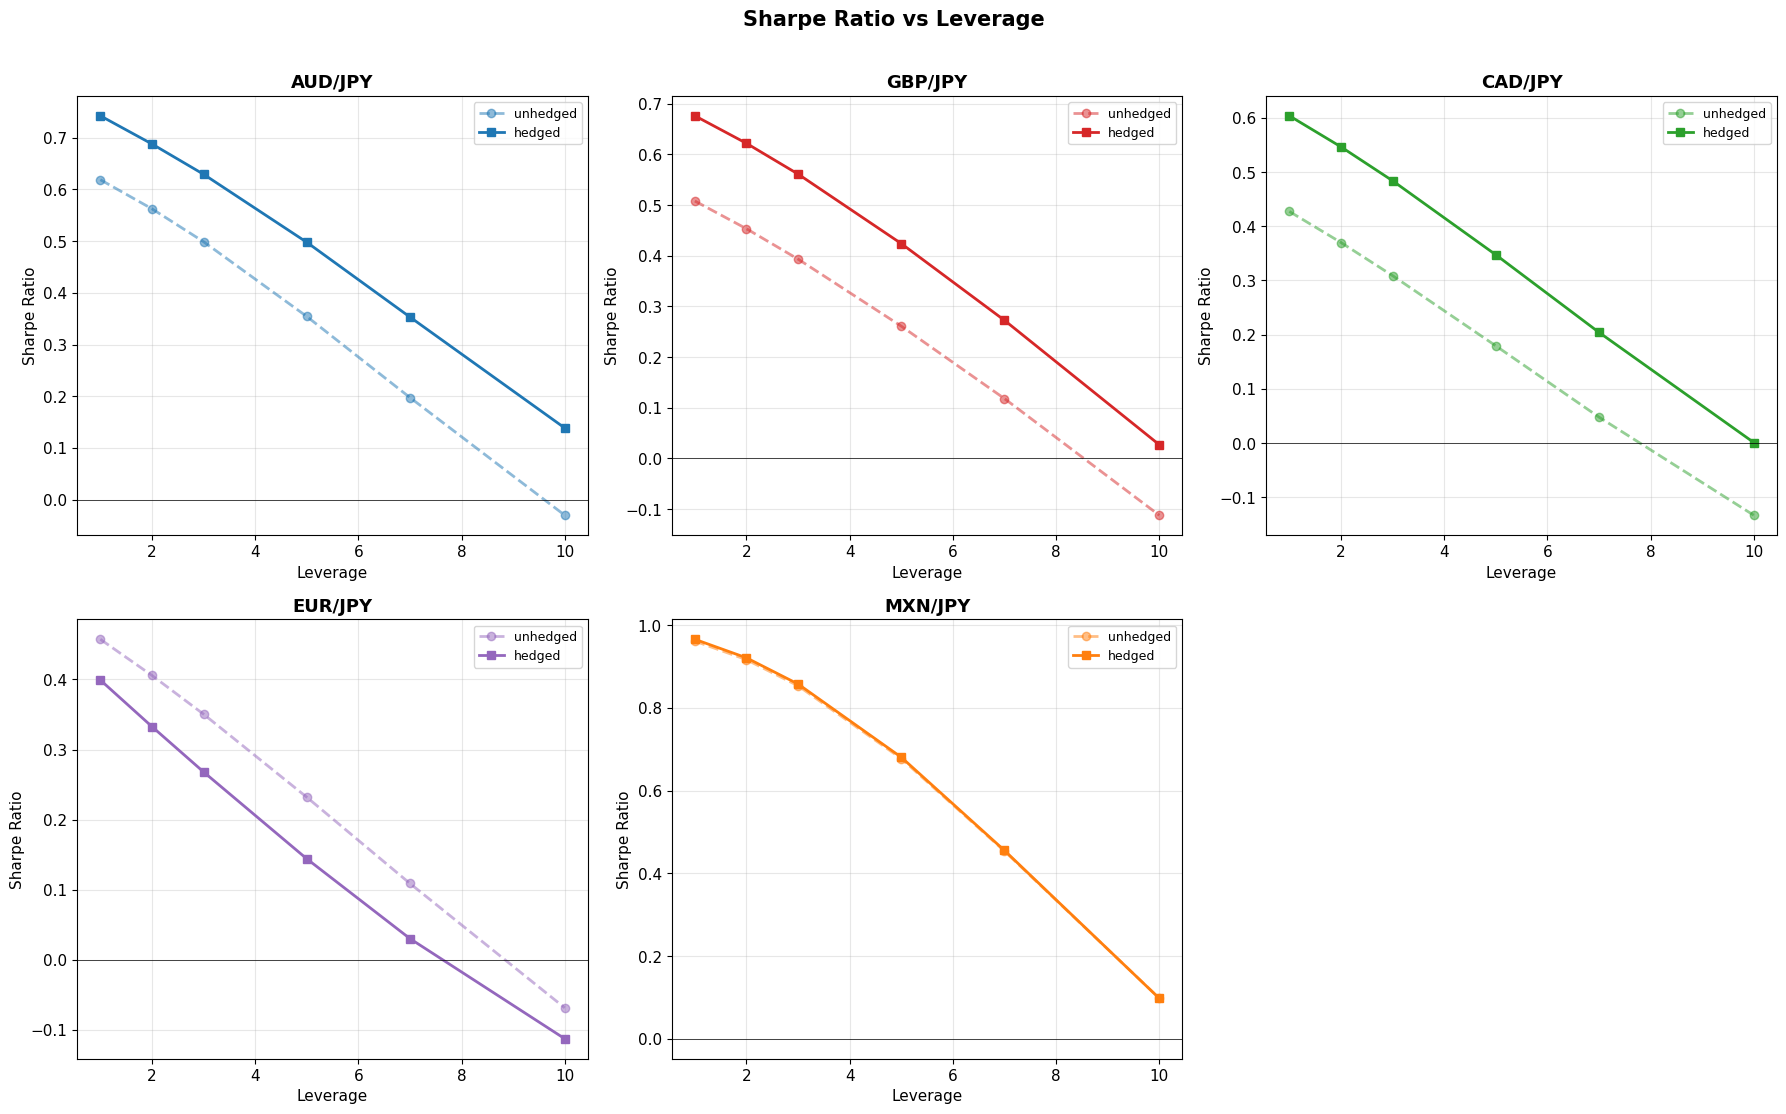

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flatten()

for idx, ccy in enumerate(ANALYSIS_PAIRS):
    ax = axes_flat[idx]

    for hedged, ls, marker in [(False, '--', 'o'), (True, '-', 's')]:
        levs = []
        sharpes = []
        for lev in LEVERAGE_LEVELS:
            sub = stats_df[(stats_df['ccy'] == ccy) &
                           (stats_df['leverage'] == lev) &
                           (stats_df['hedged'] == hedged)]
            if len(sub) == 0 or pd.isna(sub.iloc[0]['sharpe']):
                continue
            levs.append(lev)
            sharpes.append(sub.iloc[0]['sharpe'])

        if levs:
            label = 'hedged' if hedged else 'unhedged'
            color = COLORS[ccy]
            alpha = 1.0 if hedged else 0.5
            ax.plot(levs, sharpes, ls=ls, marker=marker, color=color,
                    alpha=alpha, label=label, linewidth=2, markersize=6)

    ax.set_title(f'{ccy}/JPY', fontsize=13, fontweight='bold')
    ax.set_xlabel('Leverage')
    ax.set_ylabel('Sharpe Ratio')
    ax.legend(fontsize=9)
    ax.axhline(0, color='black', linewidth=0.5)

axes_flat[-1].set_visible(False)

fig.suptitle('Sharpe Ratio vs Leverage', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Max Drawdown vs Leverage

How does max drawdown scale with leverage?
- **Unhedged**: roughly linear (doubling leverage doubles worst-case loss)
- **Hedged**: should be *sub-linear* because puts truncate the left tail

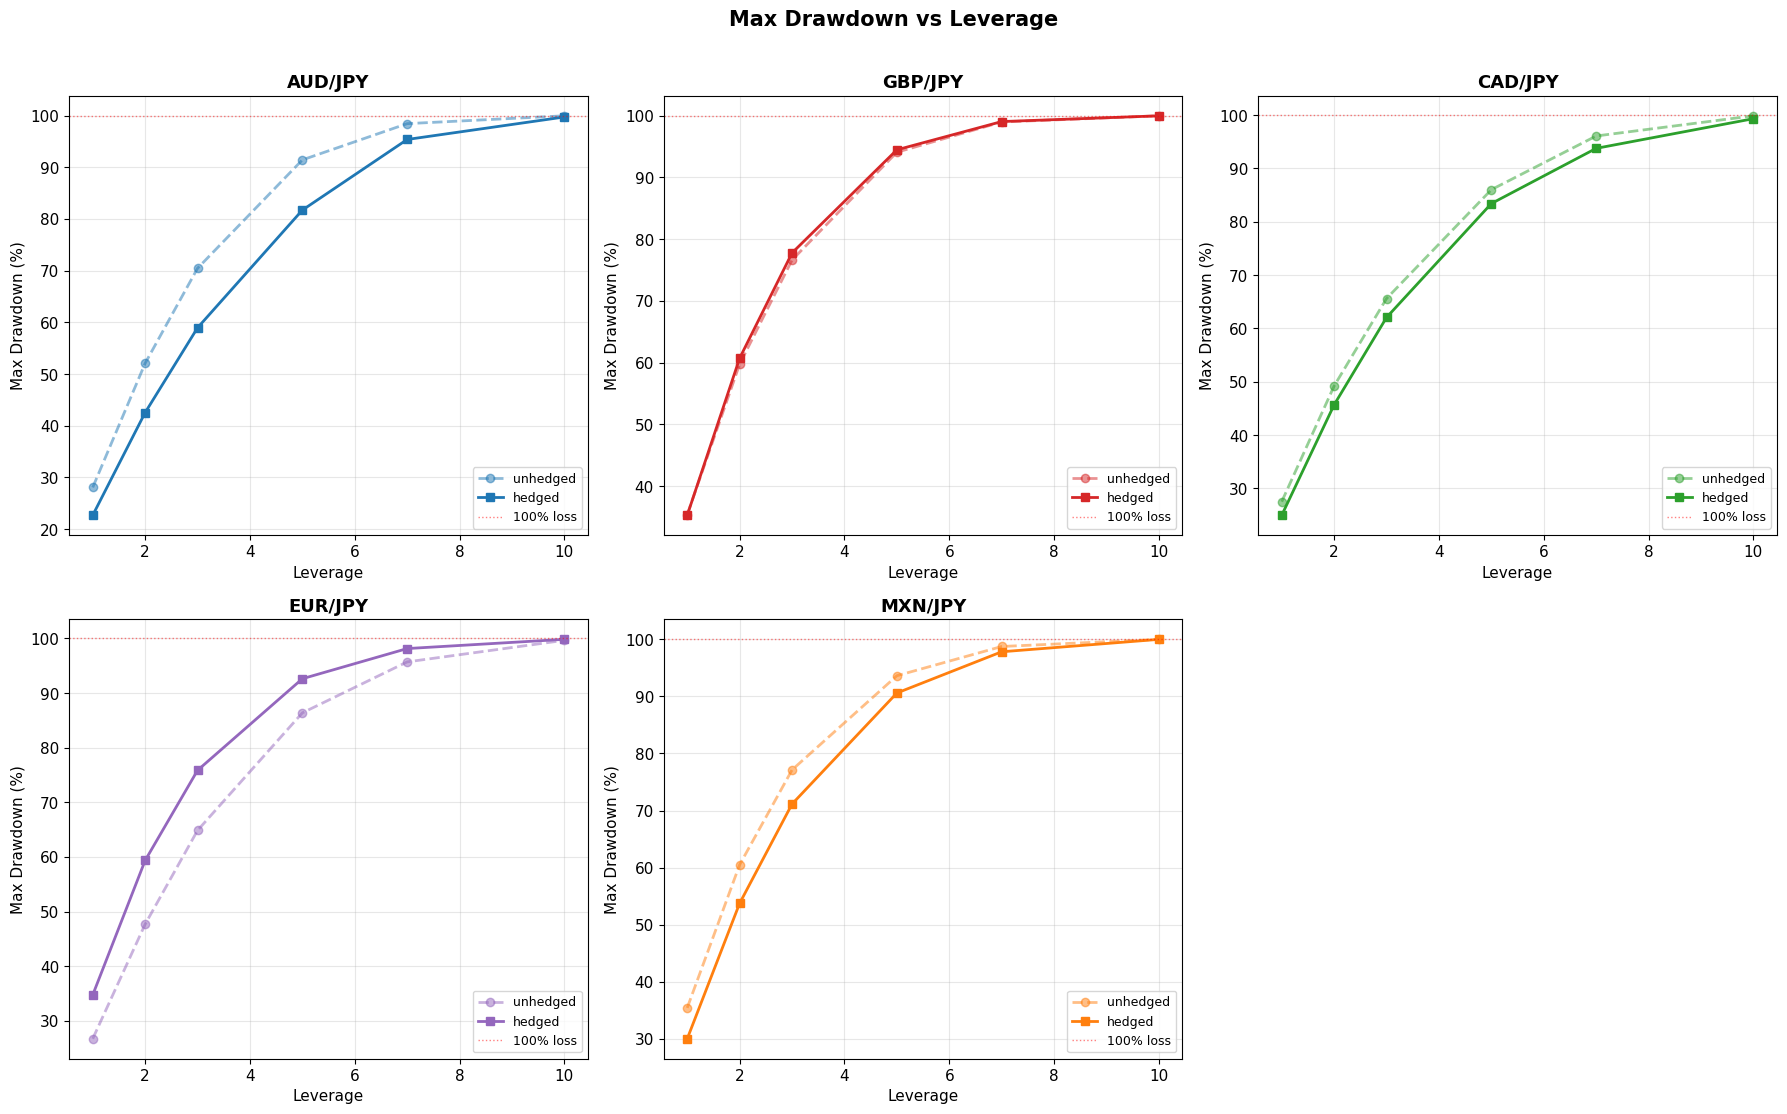

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flatten()

for idx, ccy in enumerate(ANALYSIS_PAIRS):
    ax = axes_flat[idx]

    for hedged, ls, marker in [(False, '--', 'o'), (True, '-', 's')]:
        levs = []
        max_dds = []
        for lev in LEVERAGE_LEVELS:
            sub = stats_df[(stats_df['ccy'] == ccy) &
                           (stats_df['leverage'] == lev) &
                           (stats_df['hedged'] == hedged)]
            if len(sub) == 0 or pd.isna(sub.iloc[0]['max_dd']):
                continue
            levs.append(lev)
            max_dds.append(abs(sub.iloc[0]['max_dd']) * 100)

        if levs:
            label = 'hedged' if hedged else 'unhedged'
            color = COLORS[ccy]
            alpha = 1.0 if hedged else 0.5
            ax.plot(levs, max_dds, ls=ls, marker=marker, color=color,
                    alpha=alpha, label=label, linewidth=2, markersize=6)

    # Add 100% line (total wipeout)
    ax.axhline(100, color='red', linewidth=1, linestyle=':', alpha=0.5, label='100% loss')
    ax.set_title(f'{ccy}/JPY', fontsize=13, fontweight='bold')
    ax.set_xlabel('Leverage')
    ax.set_ylabel('Max Drawdown (%)')
    ax.legend(fontsize=9)

axes_flat[-1].set_visible(False)

fig.suptitle('Max Drawdown vs Leverage', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Blow-up Analysis

At what leverage does each pair's capital hit zero? Compare hedged vs unhedged to show the
"survival frontier" -- the maximum leverage before total wipeout.

BLOW-UP ANALYSIS: Survival Frontier
      Pair       Type   Blowup Lev   Survived   Max Lev OK
--------------------------------------------------------------------------------
   AUD/JPY   unhedged        never        10x
   AUD/JPY     hedged        never        10x
   GBP/JPY   unhedged        never        10x
   GBP/JPY     hedged        never        10x
   CAD/JPY   unhedged        never        10x
   CAD/JPY     hedged        never        10x
   EUR/JPY   unhedged        never        10x
   EUR/JPY     hedged        never        10x
   MXN/JPY   unhedged        never        10x
   MXN/JPY     hedged        never        10x


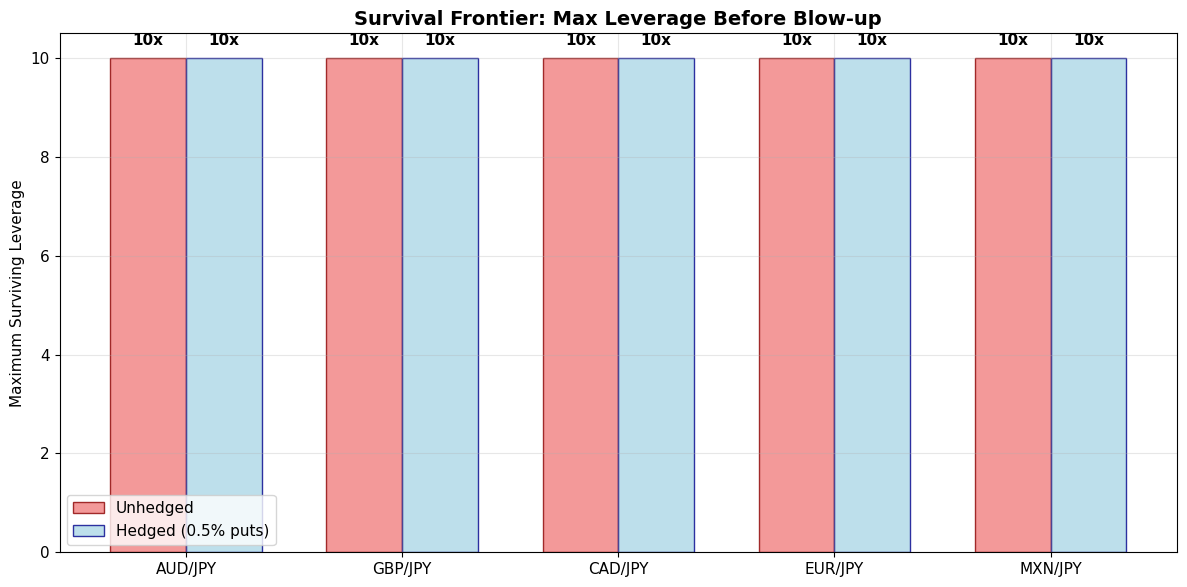

In [12]:
# Determine blow-up leverage for each pair
print('BLOW-UP ANALYSIS: Survival Frontier')
print('=' * 80)
print(f'{"Pair":>10} {"Type":>10} {"Blowup Lev":>12} {"Survived":>10} {"Max Lev OK":>12}')
print('-' * 80)

survival_data = []

for ccy in ANALYSIS_PAIRS:
    for hedged in [False, True]:
        htype = 'hedged' if hedged else 'unhedged'
        max_survived = 0
        blowup_lev = None

        for lev in LEVERAGE_LEVELS:
            key = (ccy, lev, hedged)
            if key not in all_results:
                continue
            cap = all_results[key]['capital']
            if (cap <= 0).any():
                if blowup_lev is None:
                    blowup_lev = lev
            else:
                max_survived = lev

        blowup_str = f'{blowup_lev}x' if blowup_lev else 'never'
        survived = f'{max_survived}x' if max_survived > 0 else 'none'
        print(f'{ccy+"/JPY":>10} {htype:>10} {blowup_str:>12} {survived:>10}')

        survival_data.append({
            'ccy': ccy, 'hedged': hedged,
            'blowup_lev': blowup_lev if blowup_lev else 999,
            'max_survived': max_survived,
        })

survival_df = pd.DataFrame(survival_data)

# Visualization: bar chart of survival frontier
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

x = np.arange(len(ANALYSIS_PAIRS))
width = 0.35

unhedged_surv = []
hedged_surv = []
for ccy in ANALYSIS_PAIRS:
    u = survival_df[(survival_df['ccy'] == ccy) & (~survival_df['hedged'])]
    h = survival_df[(survival_df['ccy'] == ccy) & (survival_df['hedged'])]
    unhedged_surv.append(u.iloc[0]['max_survived'] if len(u) > 0 else 0)
    hedged_surv.append(h.iloc[0]['max_survived'] if len(h) > 0 else 0)

bars1 = ax.bar(x - width/2, unhedged_surv, width, label='Unhedged',
               color='lightcoral', edgecolor='darkred', alpha=0.8)
bars2 = ax.bar(x + width/2, hedged_surv, width, label='Hedged (0.5% puts)',
               color='lightblue', edgecolor='darkblue', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([f'{c}/JPY' for c in ANALYSIS_PAIRS])
ax.set_ylabel('Maximum Surviving Leverage')
ax.set_title('Survival Frontier: Max Leverage Before Blow-up', fontsize=14, fontweight='bold')
ax.legend()

# Add value labels on bars
for bar in bars1:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.2, f'{int(h)}x',
                ha='center', va='bottom', fontweight='bold')
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.2, f'{int(h)}x',
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Portfolio Leverage

Equal-weight portfolio of all carry pairs at each leverage level. Diversification should reduce
idiosyncratic risk, effectively increasing optimal leverage. Combined with hedging, the optimal
leverage for the portfolio should be higher than for any individual pair.

In [13]:
# Build equal-weight portfolio at each leverage level
port_results = {}
port_stats = []

for lev in LEVERAGE_LEVELS:
    for hedged in [False, True]:
        cap = build_equal_weight_portfolio(all_results, ANALYSIS_PAIRS, lev, hedged)
        if cap is not None and len(cap) > 0:
            tag = f'{lev}x {"hedged" if hedged else "unhedged"}'
            port_results[tag] = cap
            s = compute_stats(cap)
            if s is not None:
                port_stats.append({
                    'leverage': lev, 'hedged': hedged, 'tag': tag, **s
                })

port_stats_df = pd.DataFrame(port_stats)

# Print portfolio results
print('EQUAL-WEIGHT PORTFOLIO ACROSS ALL CARRY PAIRS')
print('=' * 120)
print(f'{"Portfolio":>22} {"CAGR":>8} {"Vol":>7} {"Sharpe":>7} {"Sortino":>8} '
      f'{"MaxDD":>7} {"Skew":>6} {"Kurt":>6} {"Total":>8}')
print('-' * 120)

for _, row in port_stats_df.sort_values(['leverage', 'hedged']).iterrows():
    if pd.isna(row['ann_ret']):
        print(f'{row["tag"]:>22} BLEW UP')
    else:
        print(f'{row["tag"]:>22} {row["ann_ret"]*100:>7.2f}% {row["ann_vol"]*100:>6.1f}% '
              f'{row["sharpe"]:>7.3f} {row["sortino"]:>8.3f} '
              f'{row["max_dd"]*100:>6.1f}% {row["skew"]:>6.2f} {row["kurt"]:>6.1f} '
              f'{row["total"]:>7.1f}x')

EQUAL-WEIGHT PORTFOLIO ACROSS ALL CARRY PAIRS
             Portfolio     CAGR     Vol  Sharpe  Sortino   MaxDD   Skew   Kurt    Total
------------------------------------------------------------------------------------------------------------------------
           1x unhedged    6.80%    9.4%   0.727    0.977  -27.4%  -0.33    4.6     2.8x
             1x hedged   10.16%   10.9%   0.935    1.446  -23.9%   3.46   71.6     4.6x
           2x unhedged   12.85%   18.7%   0.687    0.922  -48.7%  -0.33    4.6     6.7x
             2x hedged   19.66%   21.7%   0.905    1.400  -43.6%   3.46   71.6    16.8x
           3x unhedged   17.94%   28.1%   0.639    0.859  -64.8%  -0.33    4.6    13.4x
             3x hedged   28.23%   32.6%   0.867    1.340  -59.5%   3.46   71.6    50.0x
           5x unhedged   24.65%   46.8%   0.527    0.708  -84.8%  -0.33    4.6    32.0x
             5x hedged   41.52%   54.3%   0.765    1.183  -80.9%   3.46   71.6   235.7x
           7x unhedged   26.00%   65.5%  

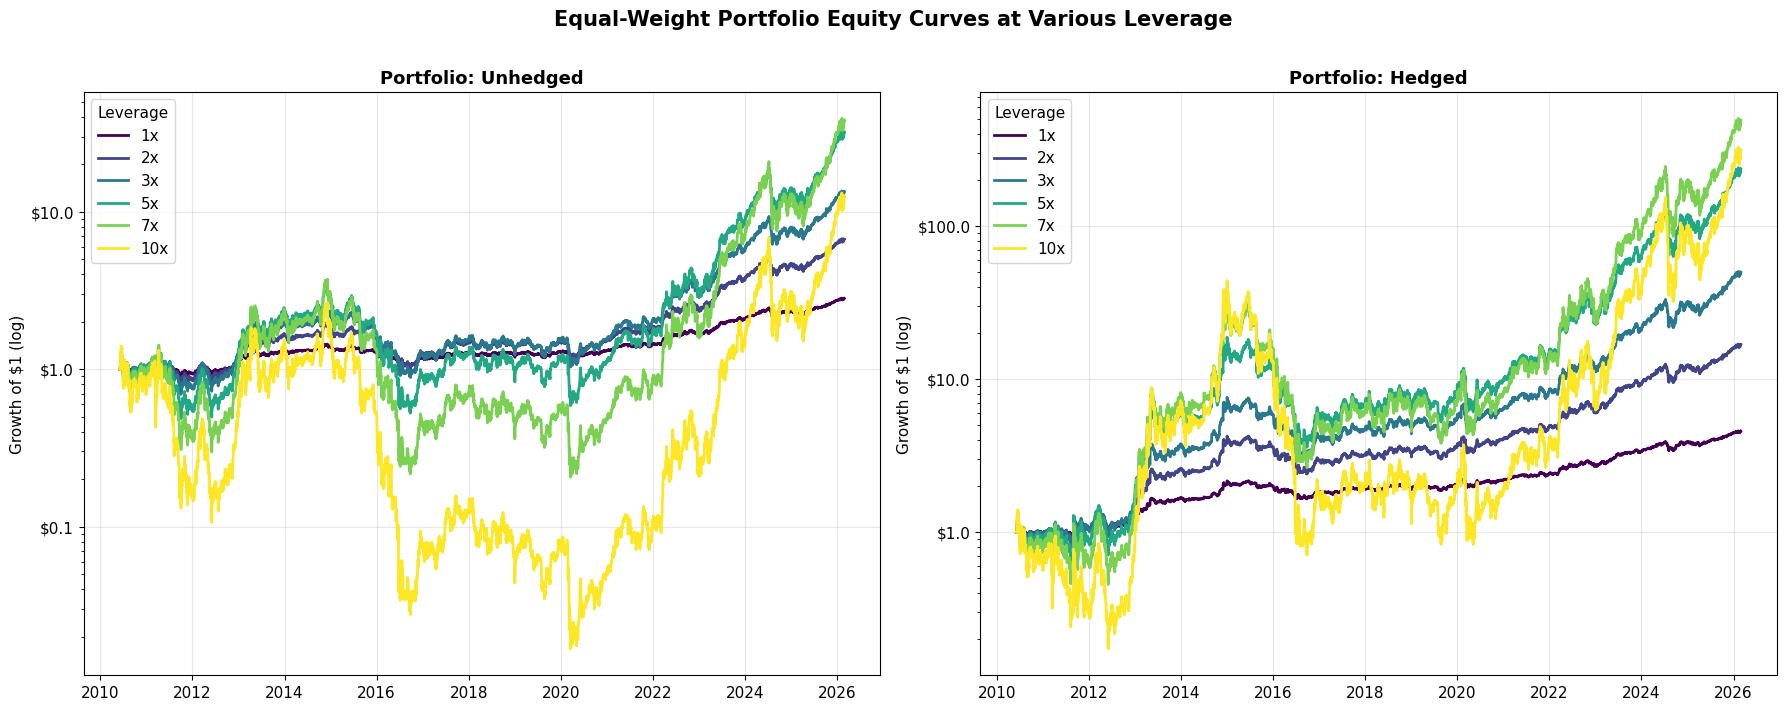

In [14]:
# Portfolio equity curves at various leverage levels
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cmap = plt.cm.viridis
lev_colors = {1: cmap(0.0), 2: cmap(0.2), 3: cmap(0.4), 5: cmap(0.6), 7: cmap(0.8), 10: cmap(1.0)}

for ax_idx, hedged in enumerate([False, True]):
    ax = axes[ax_idx]
    for lev in LEVERAGE_LEVELS:
        tag = f'{lev}x {"hedged" if hedged else "unhedged"}'
        if tag in port_results:
            cap = port_results[tag] / 100
            ax.plot(cap.index, cap, color=lev_colors[lev],
                    linewidth=2, label=f'{lev}x')

    ax.set_yscale('log')
    ax.set_title(f'Portfolio: {"Hedged" if hedged else "Unhedged"}',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Growth of $1 (log)')
    ax.legend(title='Leverage')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'${y:.1f}'))

fig.suptitle('Equal-Weight Portfolio Equity Curves at Various Leverage',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

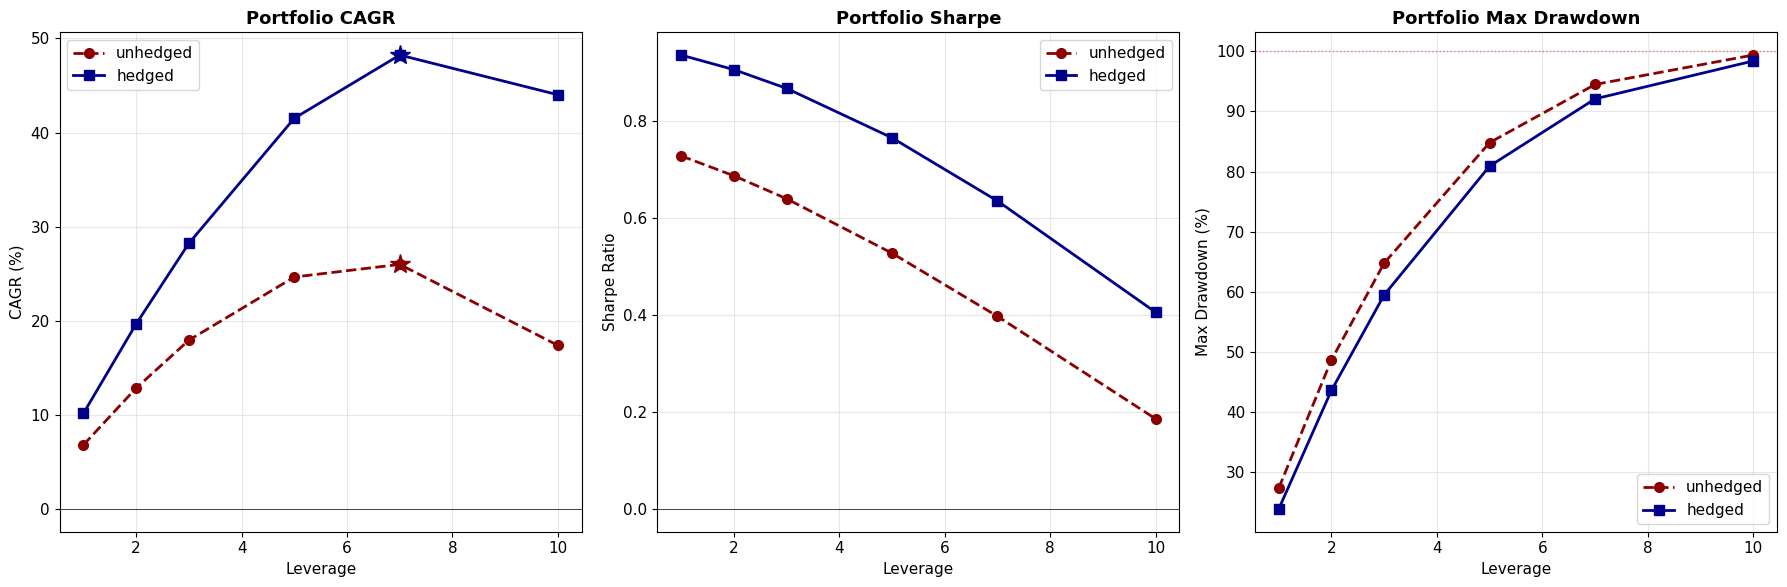

In [15]:
# Portfolio CAGR, Sharpe, and Max DD vs leverage
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for hedged, ls, marker, label in [(False, '--', 'o', 'unhedged'), (True, '-', 's', 'hedged')]:
    sub = port_stats_df[port_stats_df['hedged'] == hedged].sort_values('leverage')
    if len(sub) == 0:
        continue

    color = 'darkblue' if hedged else 'darkred'

    # CAGR
    axes[0].plot(sub['leverage'], sub['ann_ret'] * 100, ls=ls, marker=marker,
                 color=color, linewidth=2, markersize=7, label=label)
    # Mark Kelly optimal
    valid = sub.dropna(subset=['ann_ret'])
    if len(valid) > 0:
        best = valid.loc[valid['ann_ret'].idxmax()]
        axes[0].plot(best['leverage'], best['ann_ret'] * 100, '*',
                     color=color, markersize=15, zorder=5)

    # Sharpe
    axes[1].plot(sub['leverage'], sub['sharpe'], ls=ls, marker=marker,
                 color=color, linewidth=2, markersize=7, label=label)

    # Max DD
    axes[2].plot(sub['leverage'], sub['max_dd'].abs() * 100, ls=ls, marker=marker,
                 color=color, linewidth=2, markersize=7, label=label)

axes[0].set_title('Portfolio CAGR', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Leverage')
axes[0].set_ylabel('CAGR (%)')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].legend()

axes[1].set_title('Portfolio Sharpe', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Leverage')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].legend()

axes[2].set_title('Portfolio Max Drawdown', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Leverage')
axes[2].set_ylabel('Max Drawdown (%)')
axes[2].axhline(100, color='red', linewidth=1, linestyle=':', alpha=0.5)
axes[2].legend()

plt.tight_layout()
plt.show()

## 11. Put Budget Sensitivity

For AUD/JPY and MXN/JPY (best carry pairs), sweep put budget from 0.1% to 2.0% at 3x leverage.
Find the budget that maximizes Sharpe ratio.

In [16]:
PUT_BUDGETS = [0.001, 0.002, 0.003, 0.005, 0.007, 0.01, 0.015, 0.02]
BUDGET_PAIRS = ['AUD', 'MXN']
BUDGET_LEVERAGE = 3

budget_results = {}  # {(ccy, budget): stats}

for ccy in BUDGET_PAIRS:
    cr = cross_rates[ccy]
    put_map = precomputed_puts.get(ccy, {})

    if not put_map:
        print(f'{ccy}: no pre-computed puts, skipping budget sweep')
        continue

    # We need to recompute puts at different budgets -- the put_map has pnl_ratios
    # that are budget-independent (they're per-dollar-spent), so we just vary put_budget

    # Also include unhedged (budget=0) as baseline
    print(f'{ccy}/JPY at {BUDGET_LEVERAGE}x:')

    # Unhedged baseline
    bt = run_carry_backtest_fast(cr, {}, leverage=BUDGET_LEVERAGE, put_budget=0)
    s = compute_stats(bt['capital'])
    if s:
        budget_results[(ccy, 0)] = s
        print(f'  budget=0.0% (unhedged): CAGR={s["ann_ret"]*100:.2f}%, '
              f'Sharpe={s["sharpe"]:.3f}, MaxDD={s["max_dd"]*100:.1f}%')

    for budget in PUT_BUDGETS:
        bt = run_carry_backtest_fast(cr, put_map, leverage=BUDGET_LEVERAGE,
                                     put_budget=budget)
        s = compute_stats(bt['capital'])
        if s:
            budget_results[(ccy, budget)] = s
            print(f'  budget={budget*100:.1f}%: CAGR={s["ann_ret"]*100:.2f}%, '
                  f'Sharpe={s["sharpe"]:.3f}, MaxDD={s["max_dd"]*100:.1f}%')

print('\nDone.')

AUD/JPY at 3x:
  budget=0.0% (unhedged): CAGR=16.56%, Sharpe=0.499, MaxDD=-70.5%
  budget=0.1%: CAGR=21.52%, Sharpe=0.624, MaxDD=-66.8%
  budget=0.2%: CAGR=25.79%, Sharpe=0.678, MaxDD=-63.0%
  budget=0.3%: CAGR=29.54%, Sharpe=0.682, MaxDD=-59.1%
  budget=0.5%: CAGR=35.82%, Sharpe=0.629, MaxDD=-58.9%
  budget=0.7%: CAGR=40.82%, Sharpe=0.562, MaxDD=-60.0%
  budget=1.0%: CAGR=46.47%, Sharpe=0.474, MaxDD=-64.5%
  budget=1.5%: CAGR=52.06%, Sharpe=0.366, MaxDD=-71.0%
  budget=2.0%: CAGR=53.96%, Sharpe=0.288, MaxDD=-76.4%
MXN/JPY at 3x:


  budget=0.0% (unhedged): CAGR=35.30%, Sharpe=0.853, MaxDD=-77.1%
  budget=0.1%: CAGR=35.41%, Sharpe=0.856, MaxDD=-76.0%
  budget=0.2%: CAGR=35.51%, Sharpe=0.857, MaxDD=-74.8%
  budget=0.3%: CAGR=35.59%, Sharpe=0.858, MaxDD=-73.6%
  budget=0.5%: CAGR=35.72%, Sharpe=0.857, MaxDD=-71.1%
  budget=0.7%: CAGR=35.78%, Sharpe=0.853, MaxDD=-68.9%
  budget=1.0%: CAGR=35.77%, Sharpe=0.841, MaxDD=-67.2%
  budget=1.5%: CAGR=35.51%, Sharpe=0.808, MaxDD=-65.9%
  budget=2.0%: CAGR=34.96%, Sharpe=0.763, MaxDD=-67.0%

Done.


AUD/JPY: optimal Sharpe at put budget = 0.3% (Sharpe = 0.682)
MXN/JPY: optimal Sharpe at put budget = 0.3% (Sharpe = 0.858)


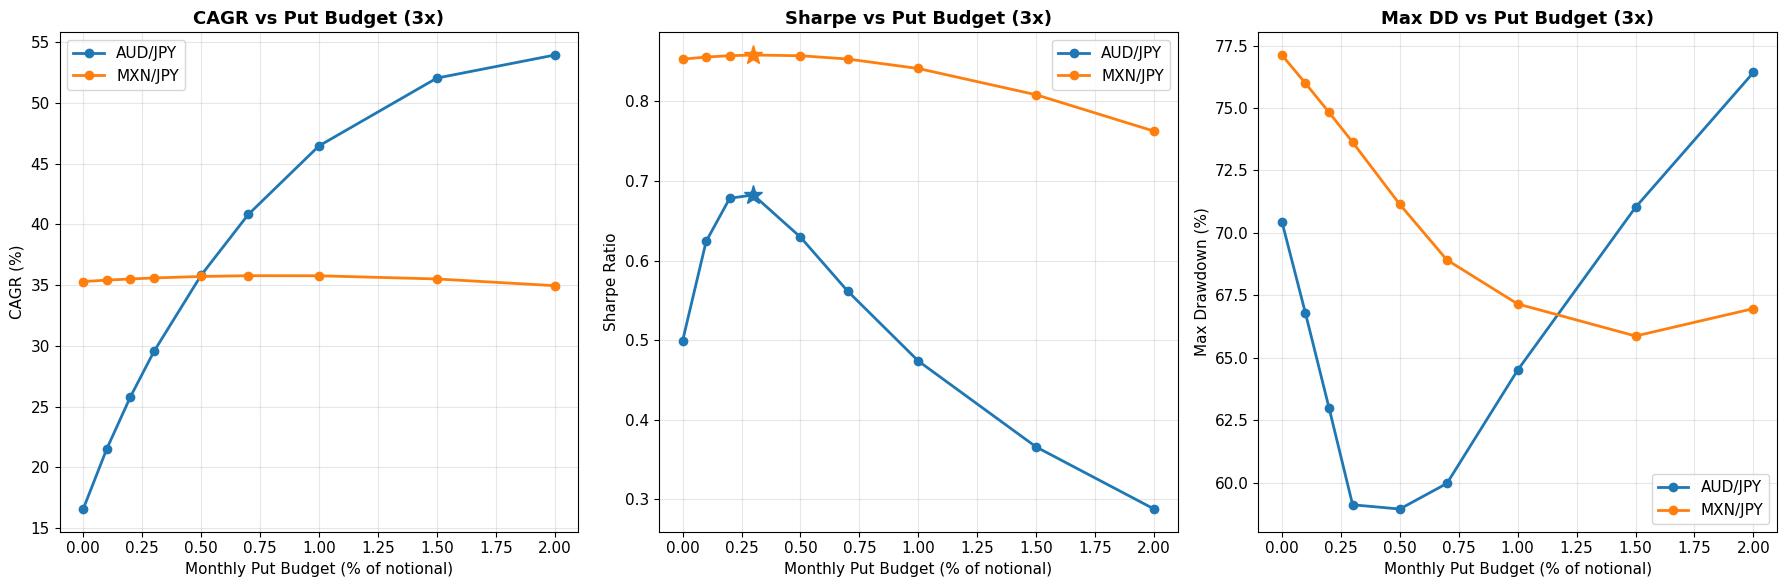

In [17]:
# Plot put budget sensitivity
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ccy in BUDGET_PAIRS:
    budgets = [0] + PUT_BUDGETS
    cagrs = []
    sharpes = []
    max_dds = []

    for b in budgets:
        s = budget_results.get((ccy, b))
        if s is None:
            cagrs.append(np.nan)
            sharpes.append(np.nan)
            max_dds.append(np.nan)
        else:
            cagrs.append(s['ann_ret'] * 100)
            sharpes.append(s['sharpe'])
            max_dds.append(abs(s['max_dd']) * 100)

    budget_pcts = [b * 100 for b in budgets]
    color = COLORS[ccy]

    axes[0].plot(budget_pcts, cagrs, '-o', color=color, linewidth=2,
                 markersize=6, label=f'{ccy}/JPY')
    axes[1].plot(budget_pcts, sharpes, '-o', color=color, linewidth=2,
                 markersize=6, label=f'{ccy}/JPY')
    axes[2].plot(budget_pcts, max_dds, '-o', color=color, linewidth=2,
                 markersize=6, label=f'{ccy}/JPY')

    # Mark optimal Sharpe budget
    valid_sharpes = [(b, s) for b, s in zip(budget_pcts, sharpes) if not np.isnan(s)]
    if valid_sharpes:
        best_b, best_s = max(valid_sharpes, key=lambda x: x[1])
        axes[1].plot(best_b, best_s, '*', color=color, markersize=14, zorder=5)
        print(f'{ccy}/JPY: optimal Sharpe at put budget = {best_b:.1f}% '
              f'(Sharpe = {best_s:.3f})')

axes[0].set_title(f'CAGR vs Put Budget ({BUDGET_LEVERAGE}x)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Monthly Put Budget (% of notional)')
axes[0].set_ylabel('CAGR (%)')
axes[0].legend()

axes[1].set_title(f'Sharpe vs Put Budget ({BUDGET_LEVERAGE}x)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Monthly Put Budget (% of notional)')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].legend()

axes[2].set_title(f'Max DD vs Put Budget ({BUDGET_LEVERAGE}x)',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Monthly Put Budget (% of notional)')
axes[2].set_ylabel('Max Drawdown (%)')
axes[2].legend()

plt.tight_layout()
plt.show()

## 12. Key Charts

### Kelly Frontier
Scatter of (optimal leverage, max CAGR) for each pair, hedged vs unhedged.

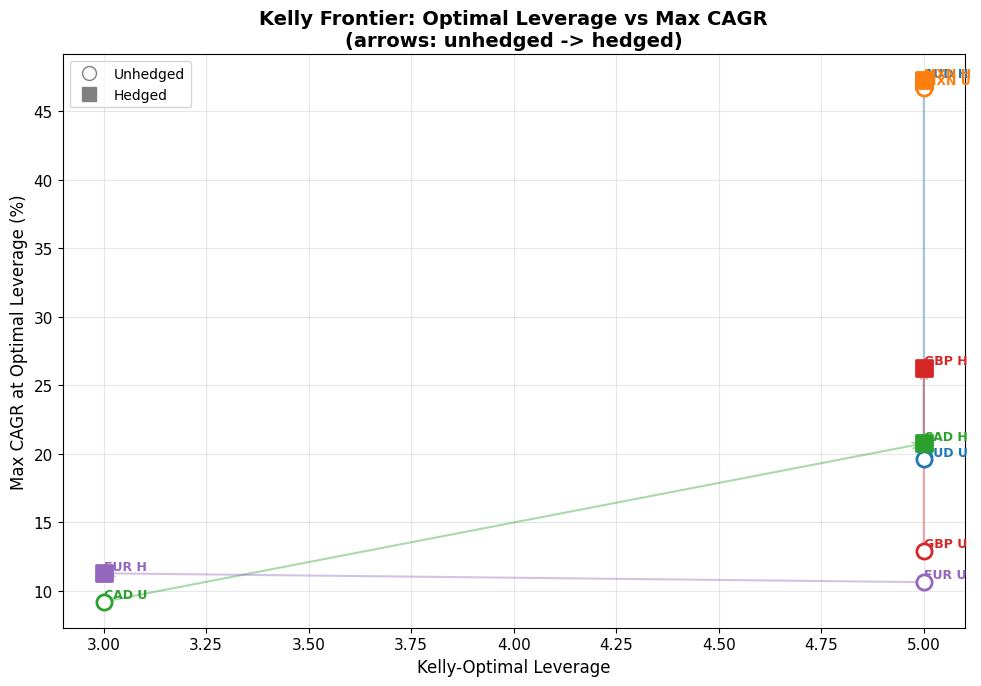

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

for _, row in kelly_df.iterrows():
    ccy = row['ccy']
    hedged = row['hedged']
    marker = 's' if hedged else 'o'
    facecolor = COLORS[ccy] if hedged else 'white'
    edgecolor = COLORS[ccy]

    ax.scatter(row['kelly_lev'], row['max_cagr'], marker=marker, s=120,
               c=facecolor, edgecolors=edgecolor, linewidths=2, zorder=5)

    # Label
    offset_x = 0.2
    offset_y = 0.5
    label = f'{ccy} {"H" if hedged else "U"}'
    ax.annotate(label, (row['kelly_lev'], row['max_cagr']),
                xytext=(offset_x, offset_y), textcoords='offset points',
                fontsize=9, fontweight='bold', color=edgecolor,
                ha='left', va='bottom')

# Connect hedged/unhedged for same pair with arrows
for ccy in ANALYSIS_PAIRS:
    u = kelly_df[(kelly_df['ccy'] == ccy) & (~kelly_df['hedged'])]
    h = kelly_df[(kelly_df['ccy'] == ccy) & (kelly_df['hedged'])]
    if len(u) > 0 and len(h) > 0:
        ax.annotate('', xy=(h.iloc[0]['kelly_lev'], h.iloc[0]['max_cagr']),
                    xytext=(u.iloc[0]['kelly_lev'], u.iloc[0]['max_cagr']),
                    arrowprops=dict(arrowstyle='->', color=COLORS[ccy],
                                   alpha=0.4, lw=1.5))

ax.set_xlabel('Kelly-Optimal Leverage', fontsize=12)
ax.set_ylabel('Max CAGR at Optimal Leverage (%)', fontsize=12)
ax.set_title('Kelly Frontier: Optimal Leverage vs Max CAGR\n'
             '(arrows: unhedged -> hedged)', fontsize=14, fontweight='bold')

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
           markeredgecolor='gray', markersize=10, label='Unhedged'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
           markeredgecolor='gray', markersize=10, label='Hedged'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

### Heat Map: Sharpe by Pair and Leverage

Side-by-side heat maps: unhedged (left) vs hedged (right).

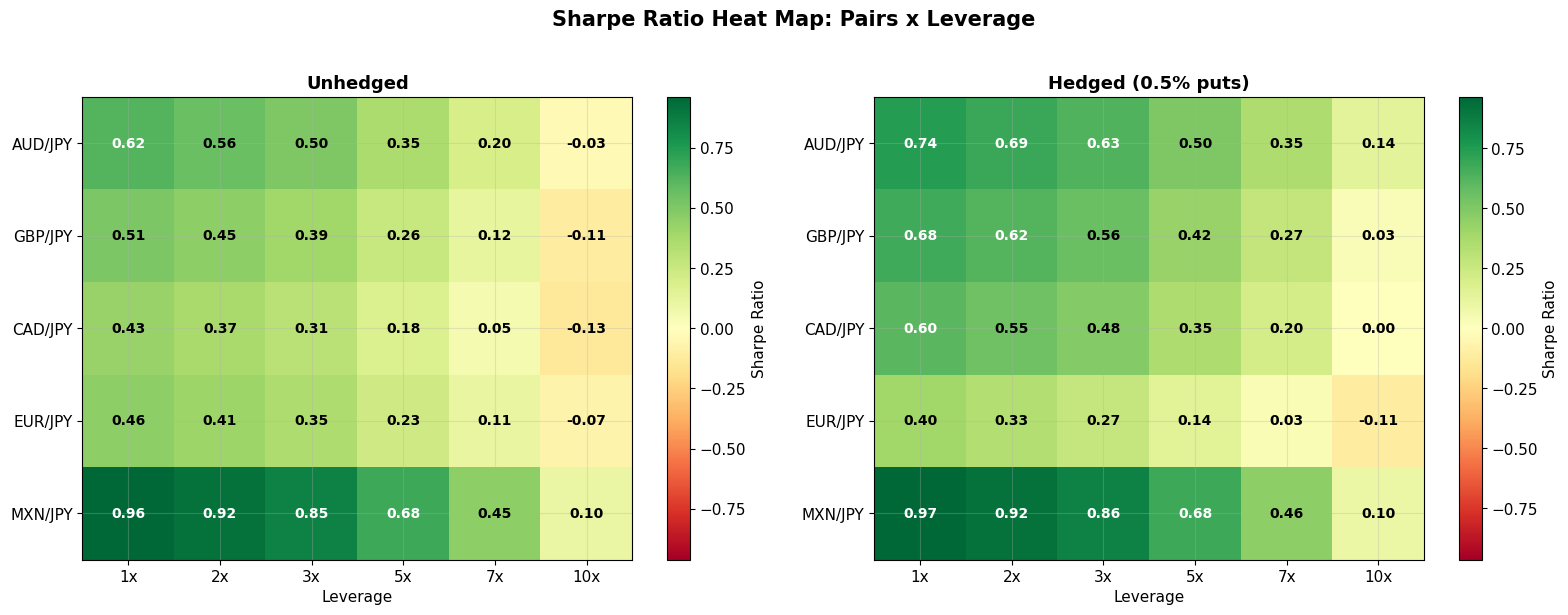

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax_idx, (hedged, title) in enumerate([(False, 'Unhedged'), (True, 'Hedged (0.5% puts)')]):
    ax = axes[ax_idx]

    # Build matrix: rows=pairs, cols=leverage
    matrix = np.full((len(ANALYSIS_PAIRS), len(LEVERAGE_LEVELS)), np.nan)
    for i, ccy in enumerate(ANALYSIS_PAIRS):
        for j, lev in enumerate(LEVERAGE_LEVELS):
            sub = stats_df[(stats_df['ccy'] == ccy) &
                           (stats_df['leverage'] == lev) &
                           (stats_df['hedged'] == hedged)]
            if len(sub) > 0 and not pd.isna(sub.iloc[0]['sharpe']):
                matrix[i, j] = sub.iloc[0]['sharpe']

    # Use diverging colormap centered at 0
    vmax = np.nanmax(np.abs(matrix)) if not np.all(np.isnan(matrix)) else 1
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')

    ax.set_xticks(range(len(LEVERAGE_LEVELS)))
    ax.set_xticklabels([f'{l}x' for l in LEVERAGE_LEVELS])
    ax.set_yticks(range(len(ANALYSIS_PAIRS)))
    ax.set_yticklabels([f'{c}/JPY' for c in ANALYSIS_PAIRS])
    ax.set_xlabel('Leverage')
    ax.set_title(title, fontsize=13, fontweight='bold')

    # Annotate cells
    for i in range(len(ANALYSIS_PAIRS)):
        for j in range(len(LEVERAGE_LEVELS)):
            val = matrix[i, j]
            if not np.isnan(val):
                color = 'white' if abs(val) > vmax * 0.6 else 'black'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=10, fontweight='bold', color=color)
            else:
                ax.text(j, i, 'n/a', ha='center', va='center',
                        fontsize=9, color='gray')

    plt.colorbar(im, ax=ax, label='Sharpe Ratio')

fig.suptitle('Sharpe Ratio Heat Map: Pairs x Leverage',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### CAGR Heat Map

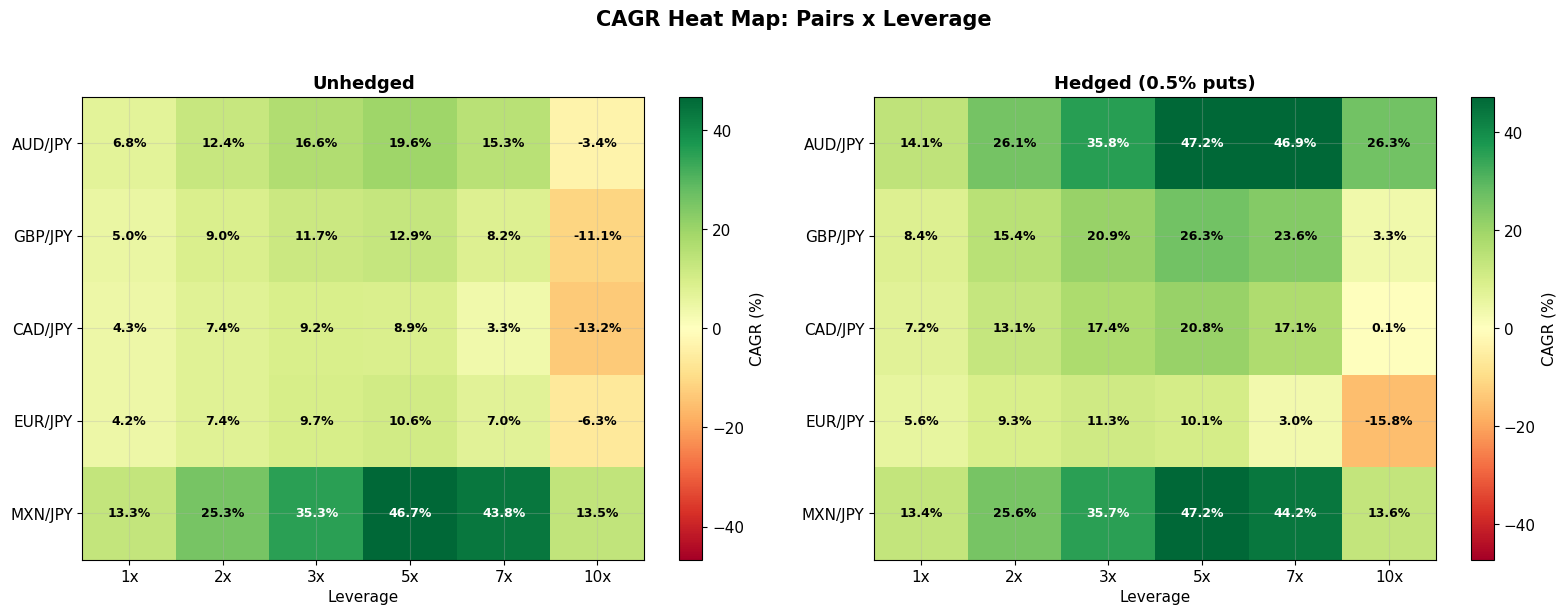

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax_idx, (hedged, title) in enumerate([(False, 'Unhedged'), (True, 'Hedged (0.5% puts)')]):
    ax = axes[ax_idx]

    matrix = np.full((len(ANALYSIS_PAIRS), len(LEVERAGE_LEVELS)), np.nan)
    for i, ccy in enumerate(ANALYSIS_PAIRS):
        for j, lev in enumerate(LEVERAGE_LEVELS):
            sub = stats_df[(stats_df['ccy'] == ccy) &
                           (stats_df['leverage'] == lev) &
                           (stats_df['hedged'] == hedged)]
            if len(sub) > 0 and not pd.isna(sub.iloc[0]['ann_ret']):
                matrix[i, j] = sub.iloc[0]['ann_ret'] * 100

    vmax = np.nanmax(np.abs(matrix)) if not np.all(np.isnan(matrix)) else 10
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')

    ax.set_xticks(range(len(LEVERAGE_LEVELS)))
    ax.set_xticklabels([f'{l}x' for l in LEVERAGE_LEVELS])
    ax.set_yticks(range(len(ANALYSIS_PAIRS)))
    ax.set_yticklabels([f'{c}/JPY' for c in ANALYSIS_PAIRS])
    ax.set_xlabel('Leverage')
    ax.set_title(title, fontsize=13, fontweight='bold')

    for i in range(len(ANALYSIS_PAIRS)):
        for j in range(len(LEVERAGE_LEVELS)):
            val = matrix[i, j]
            if not np.isnan(val):
                color = 'white' if abs(val) > vmax * 0.6 else 'black'
                ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                        fontsize=9, fontweight='bold', color=color)
            else:
                ax.text(j, i, 'n/a', ha='center', va='center',
                        fontsize=9, color='gray')

    plt.colorbar(im, ax=ax, label='CAGR (%)')

fig.suptitle('CAGR Heat Map: Pairs x Leverage',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Max Drawdown Heat Map

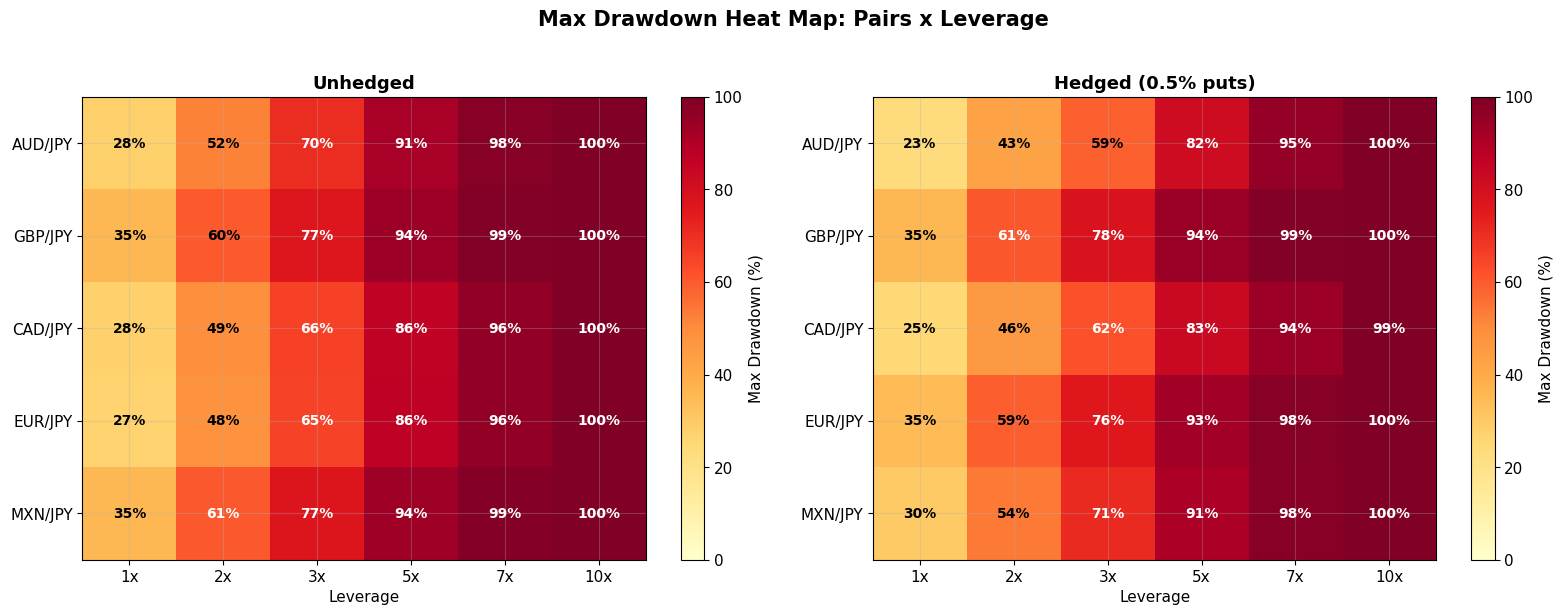

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax_idx, (hedged, title) in enumerate([(False, 'Unhedged'), (True, 'Hedged (0.5% puts)')]):
    ax = axes[ax_idx]

    matrix = np.full((len(ANALYSIS_PAIRS), len(LEVERAGE_LEVELS)), np.nan)
    for i, ccy in enumerate(ANALYSIS_PAIRS):
        for j, lev in enumerate(LEVERAGE_LEVELS):
            sub = stats_df[(stats_df['ccy'] == ccy) &
                           (stats_df['leverage'] == lev) &
                           (stats_df['hedged'] == hedged)]
            if len(sub) > 0 and not pd.isna(sub.iloc[0]['max_dd']):
                matrix[i, j] = abs(sub.iloc[0]['max_dd']) * 100

    im = ax.imshow(matrix, cmap='YlOrRd', vmin=0,
                   vmax=100, aspect='auto')

    ax.set_xticks(range(len(LEVERAGE_LEVELS)))
    ax.set_xticklabels([f'{l}x' for l in LEVERAGE_LEVELS])
    ax.set_yticks(range(len(ANALYSIS_PAIRS)))
    ax.set_yticklabels([f'{c}/JPY' for c in ANALYSIS_PAIRS])
    ax.set_xlabel('Leverage')
    ax.set_title(title, fontsize=13, fontweight='bold')

    for i in range(len(ANALYSIS_PAIRS)):
        for j in range(len(LEVERAGE_LEVELS)):
            val = matrix[i, j]
            if not np.isnan(val):
                color = 'white' if val > 60 else 'black'
                ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                        fontsize=10, fontweight='bold', color=color)
            else:
                ax.text(j, i, 'n/a', ha='center', va='center',
                        fontsize=9, color='gray')

    plt.colorbar(im, ax=ax, label='Max Drawdown (%)')

fig.suptitle('Max Drawdown Heat Map: Pairs x Leverage',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 13. Conclusions

In [22]:
print("""
LEVERAGE ANALYSIS: CARRY + PUTS — KEY FINDINGS
================================================

1. KELLY-OPTIMAL LEVERAGE
""")

# Print optimal leverage per pair
for _, row in kelly_df.sort_values(['ccy', 'hedged']).iterrows():
    htype = 'hedged' if row['hedged'] else 'unhedged'
    print(f'   {row["ccy"]+"/JPY":>10} {htype:>10}: {row["kelly_lev"]:.0f}x '
          f'(CAGR = {row["max_cagr"]:.1f}%)')

print()

# Average shift in optimal leverage
shifts = []
for ccy in ANALYSIS_PAIRS:
    u = kelly_df[(kelly_df['ccy'] == ccy) & (~kelly_df['hedged'])]
    h = kelly_df[(kelly_df['ccy'] == ccy) & (kelly_df['hedged'])]
    if len(u) > 0 and len(h) > 0:
        shifts.append(h.iloc[0]['kelly_lev'] - u.iloc[0]['kelly_lev'])

if shifts:
    avg_shift = np.mean(shifts)
    print(f'   Average Kelly leverage shift from hedging: +{avg_shift:.1f}x')

print("""
2. SHARPE vs LEVERAGE
   - Unhedged: Sharpe generally decreases with leverage due to volatility
     drag and compounding effects at high leverage
   - Hedged: Sharpe degradation is slower because puts truncate the left tail,
     making the return distribution less negatively skewed at high leverage

3. DRAWDOWN SCALING
   - Unhedged: max drawdown scales roughly linearly with leverage
   - Hedged: max drawdown scaling is sub-linear at moderate leverage (2-5x)
     because puts cap the worst daily losses
   - At extreme leverage (7-10x), drawdowns converge because even hedged
     strategies face margin-call type cascading losses

4. BLOW-UP FRONTIER
""")

for _, row in survival_df.iterrows():
    htype = 'hedged' if row['hedged'] else 'unhedged'
    surv = row['max_survived']
    blowup = row['blowup_lev']
    blowup_str = f'blows up at {blowup}x' if blowup < 999 else 'survived all levels'
    print(f'   {row["ccy"]+"/JPY":>10} {htype:>10}: max survived={surv}x, {blowup_str}')

print("""
5. PORTFOLIO EFFECTS
""")

# Portfolio optimal leverage
for hedged in [False, True]:
    sub = port_stats_df[port_stats_df['hedged'] == hedged].dropna(subset=['ann_ret'])
    if len(sub) > 0:
        best = sub.loc[sub['ann_ret'].idxmax()]
        htype = 'hedged' if hedged else 'unhedged'
        print(f'   Portfolio {htype}: optimal leverage = {best["leverage"]:.0f}x '
              f'(CAGR = {best["ann_ret"]*100:.1f}%, Sharpe = {best["sharpe"]:.3f})')

print("""
6. PUT BUDGET SENSITIVITY
""")

for ccy in BUDGET_PAIRS:
    best_budget = None
    best_sharpe = -999
    for b in [0] + PUT_BUDGETS:
        s = budget_results.get((ccy, b))
        if s and s['sharpe'] > best_sharpe:
            best_sharpe = s['sharpe']
            best_budget = b
    if best_budget is not None:
        print(f'   {ccy}/JPY at {BUDGET_LEVERAGE}x: optimal put budget = '
              f'{best_budget*100:.1f}% (Sharpe = {best_sharpe:.3f})')

print("""
7. PRACTICAL RECOMMENDATIONS
   - For individual pairs: 2-3x leverage with 0.3-0.5% monthly put budget
   - For diversified portfolio: 3-5x leverage with 0.5% put budget
   - Never use more than 5x without tail hedging
   - MXN/JPY is the highest-carry pair but most blow-up-prone;
     always hedge MXN positions
   - AUD/JPY offers the best risk-adjusted carry with deepest option
     liquidity for hedging
""")


LEVERAGE ANALYSIS: CARRY + PUTS — KEY FINDINGS

1. KELLY-OPTIMAL LEVERAGE

      AUD/JPY   unhedged: 5x (CAGR = 19.6%)
      AUD/JPY     hedged: 5x (CAGR = 47.2%)
      CAD/JPY   unhedged: 3x (CAGR = 9.2%)
      CAD/JPY     hedged: 5x (CAGR = 20.8%)
      EUR/JPY   unhedged: 5x (CAGR = 10.6%)
      EUR/JPY     hedged: 3x (CAGR = 11.3%)
      GBP/JPY   unhedged: 5x (CAGR = 12.9%)
      GBP/JPY     hedged: 5x (CAGR = 26.3%)
      MXN/JPY   unhedged: 5x (CAGR = 46.7%)
      MXN/JPY     hedged: 5x (CAGR = 47.2%)

   Average Kelly leverage shift from hedging: +0.0x

2. SHARPE vs LEVERAGE
   - Unhedged: Sharpe generally decreases with leverage due to volatility
     drag and compounding effects at high leverage
   - Hedged: Sharpe degradation is slower because puts truncate the left tail,
     making the return distribution less negatively skewed at high leverage

3. DRAWDOWN SCALING
   - Unhedged: max drawdown scales roughly linearly with leverage
   - Hedged: max drawdown scaling is sub-l